# Transformer 从零到工程实践

> 一份面向普通软件开发工程师的中文互动教学 notebook。我们从“为什么 RNN/CNN 不够”开始，逐步拆开原版 Encoder-Decoder Transformer，再把同一套积木映射到 GPT 和 BERT。

**这份教程默认你具备：**

- 会写 Python，能读懂基本 PyTorch 代码。
- 知道向量、矩阵乘法、softmax 的大致含义。
- 不要求你有深度学习专业背景；关键公式会逐个解释符号和实际意义。

**阅读约定**

每一章都按同一条教学链路展开：

1. 要解决什么问题？
2. 前一章留下了什么缺口？
3. 直觉是什么？
4. 数学公式怎么写，每个符号是什么意思？
5. 用一组小数字怎么手算？
6. 代码如何实现，shape 怎么流动？
7. 图上应该看到什么现象？
8. 工程里最容易错在哪里？

**最终你会得到三条主线：**

- **Original Transformer**：Encoder-Decoder，用于机器翻译、摘要等序列到序列任务。
- **GPT**：Decoder-only，用 causal mask 做 next-token prediction。
- **BERT**：Encoder-only，用双向上下文做 masked language modeling 和表示学习。

## 0 · 环境准备、随机种子和绘图风格

这一节只做四件事：

1. 导入后续要用的库。
2. 固定随机种子，让数字和图可复现。
3. 检测可用加速设备，但教学代码默认使用 CPU，避免小模型在 MPS/CUDA 上被调度开销拖慢。
4. 配置浅色 Matplotlib 风格和中文字体回退。

### 0.1 学习路线和符号约定

本教程的路线不是“先堆公式”，而是按依赖关系往前走：

```text
序列任务的问题
  -> token 如何变成向量
  -> 一个 token 如何看其他 token
  -> attention 如何变稳定、变多头
  -> mask 如何约束可见范围
  -> block 如何可训练、可堆叠
  -> encoder-decoder 如何完成翻译
  -> GPT/BERT 如何从原版结构分化出来
```

后面所有代码和公式都会反复出现这些 shape 符号：

| 符号 | 含义 | 例子 |
|---|---|---|
| `B` | batch size，一次喂给模型的样本数 | `B=32` |
| `T` | target 或通用序列长度 | decoder 输入长度 |
| `S` | source 序列长度 | encoder 输入长度 |
| `D` / `d_model` | Transformer 内部向量宽度 | `D=512` |
| `H` | attention head 数量 | `H=8` |
| `d_k` | 每个 head 的 query/key 维度 | `d_k = D / H` |
| `V` | vocabulary size，词表大小 | `V=30000` |

一个最常见的数据流是：

```text
token ids [B, T]
  -> embedding [B, T, D]
  -> attention scores [B, H, T_q, T_k]
  -> hidden states [B, T, D]
  -> logits [B, T, V]
```

先记住这条线，后面每个模块只是把其中一段拆开。

In [1]:
import math
import random
import time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FIGURE_FORMAT = "png"
try:
    ip = get_ipython()  # available inside Jupyter/IPython
    ip.run_line_magic("config", "InlineBackend.figure_formats = {'svg'}")
    FIGURE_FORMAT = "svg"
except Exception:
    try:
        from matplotlib_inline.backend_inline import set_matplotlib_formats
        set_matplotlib_formats("svg")
        FIGURE_FORMAT = "svg"
    except Exception:
        FIGURE_FORMAT = "png"

try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

if torch.backends.mps.is_available():
    accelerated_device = torch.device("mps")
elif torch.cuda.is_available():
    accelerated_device = torch.device("cuda")
else:
    accelerated_device = torch.device("cpu")

# 教学 notebook 默认使用 CPU：这些 toy 模型很小，CPU 往往比 MPS/CUDA 的调度开销更稳。
# 想实验硬件加速时，可以手动改成 accelerated_device。
device = torch.device("cpu")

_cjk_candidates = [
    "PingFang SC", "Arial Unicode MS", "Heiti TC", "Songti SC",
    "STHeiti", "Microsoft YaHei", "SimHei",
]
_installed = {f.name for f in fm.fontManager.ttflist}
_cjk = [f for f in _cjk_candidates if f in _installed]
if _cjk:
    plt.rcParams["font.sans-serif"] = _cjk + plt.rcParams.get("font.sans-serif", [])

plt.rcParams.update({
    "figure.figsize": (8.5, 4.8),
    "figure.dpi": 115,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#ffffff",
    "axes.unicode_minus": False,
})

COLORS = {
    "blue": "#2563eb",
    "green": "#059669",
    "red": "#dc2626",
    "amber": "#d97706",
    "purple": "#7c3aed",
    "teal": "#0d9488",
    "gray": "#6b7280",
    "dark": "#111827",
}

def softmax_np(x, axis=-1):
    x = np.asarray(x, dtype=np.float64)
    z = x - x.max(axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=axis, keepdims=True)

def show_matrix(mat, row_labels=None, col_labels=None, title=None, cmap="Blues", vmin=None, vmax=None, ax=None):
    mat = np.asarray(mat)
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(mat.shape[1]))
    ax.set_yticks(range(mat.shape[0]))
    if col_labels is not None:
        ax.set_xticklabels(col_labels, rotation=30, ha="right")
    if row_labels is not None:
        ax.set_yticklabels(row_labels)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=9)
    if title:
        ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax

print("Python / PyTorch ready")
print("torch:", torch.__version__)
print("device used by tutorial:", device)
print("accelerated device available:", accelerated_device)
print("widgets available:", HAS_WIDGETS)
print("figure format:", FIGURE_FORMAT)
print("CJK fonts:", _cjk if _cjk else "(none)")

Python / PyTorch ready
torch: 2.13.0
device used by tutorial: cpu
accelerated device available: mps
widgets available: True
figure format: svg
CJK fonts: ['PingFang SC', 'Arial Unicode MS', 'Heiti TC', 'Songti SC', 'STHeiti']


## 1 · 为什么需要 Transformer：先看前一代方法的缺口

Transformer 不是凭空出现的。它主要解决三个前置问题：

| 方法 | 解决了什么 | 留下的问题 |
|---|---|---|
| N-gram / 传统统计语言模型 | 用前几个词预测下一个词 | 上下文太短，词义不能随上下文变化 |
| RNN / LSTM / GRU | 按时间顺序读完整句子 | 长距离依赖难，训练不能充分并行 |
| CNN 序列模型 | 可以并行、局部模式强 | 要堆很多层才能连接远距离 token |

Transformer 的核心回答是：**让序列里的每个 token 直接看见其他 token，并且用可学习的权重决定“应该看谁”。**

这就是 attention。后面的所有结构都围绕一个问题展开：

> 对当前 token 来说，序列里的哪些 token 对我最有用？

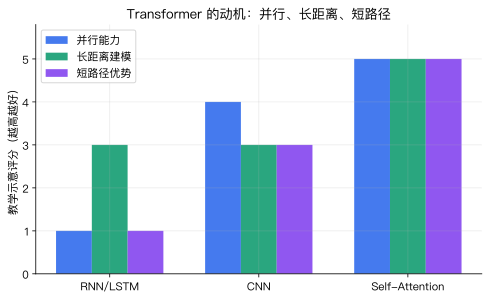

注意：这不是 benchmark 数字，而是帮助建立直觉的结构对比。
Self-Attention 的优势来自任意两个 token 之间只需要一次 attention 连接。


In [2]:
methods = ["RNN/LSTM", "CNN", "Self-Attention"]
parallel = [1, 4, 5]
long_range = [3, 3, 5]
path_len = [5, 3, 1]  # smaller is better

x = np.arange(len(methods))
width = 0.24
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width, parallel, width, label="并行能力", color=COLORS["blue"], alpha=0.85)
ax.bar(x, long_range, width, label="长距离建模", color=COLORS["green"], alpha=0.85)
ax.bar(x + width, [6 - p for p in path_len], width, label="短路径优势", color=COLORS["purple"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 5.8)
ax.set_ylabel("教学示意评分（越高越好）")
ax.set_title("Transformer 的动机：并行、长距离、短路径")
ax.legend()
plt.show()

print("注意：这不是 benchmark 数字，而是帮助建立直觉的结构对比。")
print("Self-Attention 的优势来自任意两个 token 之间只需要一次 attention 连接。")

### 1.1 一个可计算的长距离依赖例子

看这句话：

```text
The animal that the children saw near the river was tired.
```

如果当前位置是 `was`，模型需要知道主语其实是很早之前的 `animal`，而不是离它更近的 `children` 或 `river`。这就是长距离依赖。

三类结构的“信息路径长度”可以粗略理解为：

- RNN：信息要一步步从 `animal` 传到 `was`，距离越长越难。
- CNN：一层卷积只看局部窗口，要堆多层才能覆盖远处 token。
- Self-Attention：`was` 可以在一层里直接给 `animal` 一个较高权重。

下面不是严格复杂度证明，而是把这件事画成"从目标 token 找关键 token 需要跨几步"。CNN 的层数用"单侧感受野"口径估算（每加一层，感受野向一侧扩张 `(kernel-1)/2`），这和论文里 `O(n/k)` 的最大路径长度口径略有差别，只作直觉参考。

findfont: Failed to find font weight bold, now using 600.


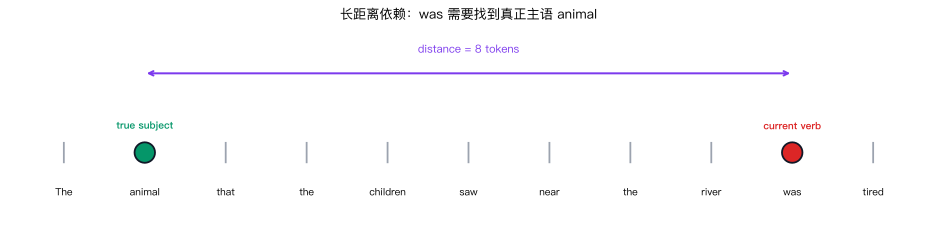

路径长度示意：
- RNN sequential path     : 8
- CNN k=3 layers (单侧口径)   : 8
- Self-attention hop      : 1

直觉：attention 不是因为参数更多才强，而是因为它把远距离 token 之间的路径缩短了。


In [3]:
sentence = ["The", "animal", "that", "the", "children", "saw", "near", "the", "river", "was", "tired"]
source_idx = sentence.index("animal")
target_idx = sentence.index("was")
distance = target_idx - source_idx

# CNN 层数估算：单侧感受野口径。每层把感受野向一侧扩张 (kernel-1)//2 = 1，
# 覆盖 distance 需要 ceil(distance / 1) 层。注意这是"单侧"口径，
# 论文常用的最大路径长度 O(n/k) 会更小（约 distance/(kernel-1)）。
cnn_kernel = 3
cnn_radius = (cnn_kernel - 1) // 2
cnn_layers_onesided = math.ceil(distance / cnn_radius)

paths = {
    "RNN sequential path": distance,
    "CNN k=3 layers (单侧口径)": cnn_layers_onesided,
    "Self-attention hop": 1,
}

fig, ax = plt.subplots(figsize=(13.5, 4.8))
x = np.arange(len(sentence))
baseline_y = 0.0
token_y = -0.28

# 用短竖线表示普通 token 的位置，把文字放在线下方，避免文字和圆点互相遮挡。
for i, tok in enumerate(sentence):
    ax.plot([i, i], [baseline_y - 0.08, baseline_y + 0.08], color="#9ca3af", lw=1.8)
    ax.text(i, token_y, tok, ha="center", va="top", fontsize=10)

# 关键 token 用彩色圆点强调；文字仍然保留在下方同一行，圆点不覆盖文字。
ax.scatter([source_idx], [baseline_y], s=420, color=COLORS["green"], edgecolor=COLORS["dark"], linewidth=1.8, zorder=3)
ax.scatter([target_idx], [baseline_y], s=420, color=COLORS["red"], edgecolor=COLORS["dark"], linewidth=1.8, zorder=3)
ax.text(source_idx, 0.18, "true subject", ha="center", va="bottom", color=COLORS["green"], fontsize=10, weight="bold")
ax.text(target_idx, 0.18, "current verb", ha="center", va="bottom", color=COLORS["red"], fontsize=10, weight="bold")

ax.annotate("", xy=(target_idx, 0.65), xytext=(source_idx, 0.65),
            arrowprops=dict(arrowstyle="<->", color=COLORS["purple"], lw=2))
ax.text((source_idx + target_idx) / 2, 0.82, f"distance = {distance} tokens",
        ha="center", color=COLORS["purple"], fontsize=11)
ax.set_xlim(-0.7, len(sentence) - 0.3)
ax.set_ylim(-0.65, 1.05)
ax.axis("off")
ax.set_title("长距离依赖：was 需要找到真正主语 animal")
plt.subplots_adjust(top=0.82, bottom=0.22, left=0.03, right=0.98)
plt.show()

print("路径长度示意：")
for name, val in paths.items():
    print(f"- {name:24s}: {val}")
print("\n直觉：attention 不是因为参数更多才强，而是因为它把远距离 token 之间的路径缩短了。")

## 2 · 输入表示：token id、embedding 和位置编码

Transformer 的第一步不是 attention，而是把离散文本变成连续向量。

设一句话有 `T` 个 token，词表大小是 `V`，向量维度是 `d_model`：

- `token_id_i`：第 `i` 个 token 在词表中的整数编号。
- `E ∈ R^(V × d_model)`：embedding 表。第 `token_id_i` 行就是这个 token 的词向量。
- `P_i ∈ R^(d_model)`：第 `i` 个位置的位置向量。
- `x_i = E[token_id_i] + P_i`：送入 Transformer 的最终输入向量。

为什么必须加位置？因为 self-attention 本身只看 token 之间的相似度，**如果不加位置，`cat bites dog` 和 `dog bites cat` 的 token 集合很像，但语义完全不同。**

token ids: [1, 2, 3, 4, 5, 6]
token embedding shape: (6, 16)  = [seq_len, d_model]
positional encoding shape: (6, 16)
final input shape: (6, 16)


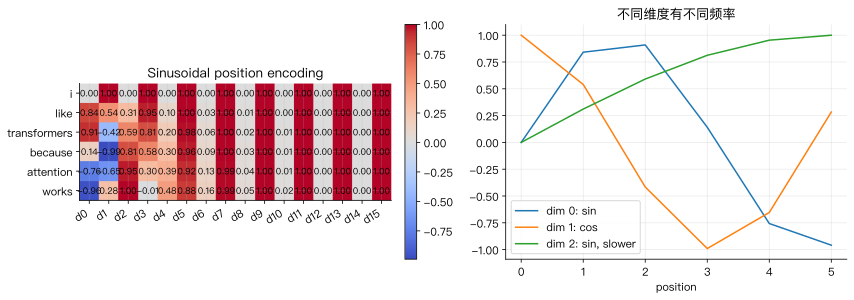

In [4]:
def sinusoidal_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1.0 / np.power(10000.0, (2 * (i // 2)) / d_model)
    angles = pos * angle_rates
    pe = np.zeros((max_len, d_model), dtype=np.float32)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

tokens = ["<pad>", "i", "like", "transformers", "because", "attention", "works"]
vocab = {tok: i for i, tok in enumerate(tokens)}
sentence = ["i", "like", "transformers", "because", "attention", "works"]
token_ids = torch.tensor([vocab[t] for t in sentence])

d_model_demo = 16
embedding = nn.Embedding(len(vocab), d_model_demo)
with torch.no_grad():
    token_vecs = embedding(token_ids)
pos_vecs = torch.tensor(sinusoidal_encoding(len(sentence), d_model_demo))
input_vecs = token_vecs + pos_vecs

print("token ids:", token_ids.tolist())
print("token embedding shape:", tuple(token_vecs.shape), " = [seq_len, d_model]")
print("positional encoding shape:", tuple(pos_vecs.shape))
print("final input shape:", tuple(input_vecs.shape))
assert token_vecs.shape == pos_vecs.shape == input_vecs.shape

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
show_matrix(pos_vecs.numpy(), row_labels=sentence, col_labels=[f"d{i}" for i in range(d_model_demo)],
            title="Sinusoidal position encoding", cmap="coolwarm", ax=axes[0])
axes[1].plot(pos_vecs[:, 0], label="dim 0: sin")
axes[1].plot(pos_vecs[:, 1], label="dim 1: cos")
axes[1].plot(pos_vecs[:, 2], label="dim 2: sin, slower")
axes[1].set_title("不同维度有不同频率")
axes[1].set_xlabel("position")
axes[1].legend()
plt.tight_layout()
plt.show()

### 2.0 位置编码公式的元素含义

原版 Transformer 使用固定的 sinusoidal positional encoding：

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

- `pos`：token 在序列中的位置，从 0 开始。
- `i`：维度对的编号。`2i` 是偶数维，`2i+1` 是奇数维。
- `d_model`：Transformer 内部向量宽度。
- `10000^(2i/d_model)`：控制不同维度的周期。低维变化快，高维变化慢。

实际含义：每个位置都有一组“多频率坐标”。模型可以通过线性组合这些坐标，学会“前一个位置”“距离两个 token”“相对顺序”等模式。

In [5]:
if HAS_WIDGETS:
    pe_demo = sinusoidal_encoding(32, 16)

    def inspect_position(pos=5, dim=0):
        fig, ax = plt.subplots(figsize=(8, 3.8))
        ax.plot(pe_demo[:, dim], marker="o", color=COLORS["blue"])
        ax.scatter([pos], [pe_demo[pos, dim]], s=90, color=COLORS["red"], zorder=5)
        ax.set_title(f"position={pos}, dim={dim}, value={pe_demo[pos, dim]:+.4f}")
        ax.set_xlabel("position")
        ax.set_ylabel("encoding value")
        plt.show()

    interact(
        inspect_position,
        pos=IntSlider(value=5, min=0, max=31, step=1, description="position"),
        dim=IntSlider(value=0, min=0, max=15, step=1, description="dim"),
    )
else:
    print("当前环境没有 ipywidgets，已跳过交互控件。")

interactive(children=(IntSlider(value=5, description='position', max=31), IntSlider(value=0, description='dim'…

### 2.1 [进阶] 位置编码的演进时间线

> 本节起到 **2.4** 属于横向进阶阅读。第一次通读教程可以直接跳到第 3 章，等理解完整 Transformer 后再回来。第 14 章末尾有一张“现代 LLM 组件替换速查表”，可作为回访索引。

上面只讲了 sinusoidal，那是 2017 年原版 Transformer 用的方案。但**位置编码不是一次定稿**——它是 Transformer 里迭代最多、直接影响长文本能力的组件之一。

下面这条时间线只列具有代表性的节点，不追求全面：

| 年份 | 方案 | 出处 | 一句话动机 |
|---|---|---|---|
| 2017 | Sinusoidal（正弦/余弦） | Vaswani et al., *Attention Is All You Need* | 用固定频率的三角函数给每个位置一个多频率坐标，无需训练参数 |
| 2018 | Learned absolute（可学习绝对位置） | GPT-1、BERT | 直接把位置当作词表，学一个 `[max_len, d_model]` 的 embedding 表 |
| 2018 | Relative position bias（相对位置偏置） | Shaw et al., *Self-Attention with Relative Position Representations* | 把“位置”从加法信号改成 attention score 里的相对偏置 |
| 2019 | T5 relative bias（分桶相对偏置） | Raffel et al., *T5* | 简化 Shaw 版：只学一个标量偏置，把相对距离分桶，支持外推 |
| 2021 | RoPE（旋转位置编码） | Su et al., *RoFormer* | 用二维旋转把位置信息乘进 Q/K，天然携带相对位置 |
| 2021 | ALiBi（线性偏置） | Press et al., *Train Short, Test Long* | 不学任何参数，直接按 `head × 距离` 的线性衰减加到 attention score |
| 2023+ | RoPE 扩展 | NTK-aware / YaRN / Position Interpolation | 让训练时短、推理时长的模型能外推到更长上下文 |

**为什么会一直改？** 三个反复出现的诉求：

1. **相对位置比绝对位置更重要**：`"the cat sat on the mat"` 里，`sat` 和 `cat` 距离 1、和 `mat` 距离 4，这种“相对距离”比“cat 在第 2 位”更本质。
2. **长度外推**：训练看到最长 2048，推理却要处理 32k。绝对位置直接失效，相对/旋转方案更容易撑住。
3. **少参数、少显存**：位置 embedding 表在长上下文时也占显存；能不学参数就不学。

### 2.2 主流方案横向对比

在细讲每一种之前，先看一张对比表。后面每一节会展开其中一行。

| 方案 | 加在哪里 | 是否需要学参数 | 绝对/相对 | 长度外推 | 典型代表模型 |
|---|---|---|---|---|---|
| Sinusoidal | 加到 embedding 上 | 否 | 绝对（隐式含相对） | 一般 | 原版 Transformer |
| Learned absolute | 加到 embedding 上 | 是 | 绝对 | 差（超过 max_len 无向量） | GPT-1、GPT-2、BERT |
| Relative bias (Shaw) | 加到 attention score | 是 | 相对 | 中等 | Transformer-XL 早期变体 |
| T5 relative bias | 加到 attention score | 是（少量） | 相对（分桶） | 好 | T5 |
| RoPE | 乘到 Q、K | 否（角度固定） | 相对 | 好（配合插值/YaRN 更好） | LLaMA、Qwen、GLM、Mistral |
| ALiBi | 加到 attention score | 否 | 相对（线性衰减） | 很好 | BLOOM、MPT |

三个判读维度：

- **加在哪里**：直接决定它作用于什么。加到 embedding 上就是“修改输入”；加到 attention score 上就是“修改注意力权重”；乘到 Q/K 上就是“通过点积隐式引入相对位置”。
- **是否需要参数**：无参数方案（sinusoidal、RoPE、ALiBi）在训练和外推上更省心。
- **绝对/相对**：相对方案通常更适合长文本。

### 2.3 逐个方案讲解

#### (a) Sinusoidal（已讲，回顾）

$$
PE(pos, 2i) = \sin(pos / 10000^{2i/d}),\quad PE(pos, 2i+1) = \cos(pos / 10000^{2i/d})
$$

**要点**：无参数、维度间频率呈几何级数、任意 `PE(pos+k)` 都是 `PE(pos)` 的线性变换，因此隐式携带相对位置。**局限**：加在 embedding 上，深层之后位置信号会被 attention/FFN 混淆，且外推能力有限。

#### (b) Learned Absolute Positional Embedding

$$
x_i = E[\text{token\_id}_i] + P[i],\quad P \in \mathbb{R}^{L_{\max} \times d}
$$

- `P` 是一张 `[max_len, d_model]` 的**可训练查找表**，每个位置有独立向量。
- 训练时和 token embedding 一起学。

**要点**：实现极简，效果和 sinusoidal 接近。BERT、GPT-1/2 都是这个。**局限**：
1. 超过 `max_len` 就没向量，**无法外推**。
2. 不显式建模相对距离。
3. 参数量 = `max_len × d_model`，长上下文时不划算。

#### (c) Relative Position Bias (Shaw 2018)

不再把位置加到输入，而是加到 attention score：

$$
score_{ij} = \frac{q_i \cdot k_j}{\sqrt{d_k}} + q_i \cdot a^K_{i-j}
$$

- `a^K_{i-j}` 是一个只依赖“相对距离 `i-j`”的可学习向量。
- 有些版本还会加一个 value 端的相对项 `a^V_{i-j}`。

**要点**：第一次让 attention **直接看到相对距离**。**局限**：每对 (i, j) 都要查表，实现较重，且相对距离范围仍要预先设定。

#### (d) T5 Relative Bias（分桶版）

T5 把上一条简化到极致：不是每个相对距离一个向量，而是把 `i - j` 分成若干**桶**，每个桶只学**一个标量**：

$$
score_{ij} = \frac{q_i \cdot k_j}{\sqrt{d_k}} + b_{\text{head},\ \text{bucket}(i-j)}
$$

- `bucket(i-j)`：近距离精细分桶，远距离对数级合并（例如 32 个桶覆盖到几千距离）。
- `b_{head, bucket}`：每个 head、每个桶一个标量偏置。

**要点**：参数极少、天然支持外推（超出训练距离只会落到最远的桶）。**局限**：粒度粗，纯标量偏置表达能力有限。

#### (e) RoPE — Rotary Position Embedding

RoPE 的核心思想：**不加位置向量，而是把 Q 和 K 按位置旋转**。把 `d` 维向量两两配对成 `(x_{2k}, x_{2k+1})`，在位置 `m` 处对每一对旋转角度 `m·θ_k`：

$$
\begin{pmatrix} q'_{2k} \\ q'_{2k+1} \end{pmatrix}
= \begin{pmatrix} \cos(m\theta_k) & -\sin(m\theta_k) \\ \sin(m\theta_k) & \cos(m\theta_k) \end{pmatrix}
\begin{pmatrix} q_{2k} \\ q_{2k+1} \end{pmatrix}
$$

其中 `θ_k = 10000^{-2k/d}`，和 sinusoidal 用同一套频率。K 做同样旋转。

**为什么有效**：旋转后的 Q、K 做点积，可以证明结果只依赖 `m - n` 这个相对距离：

$$
\langle R_m q,\ R_n k \rangle = \langle q,\ R_{n-m} k \rangle
$$

**要点**：
- 无参数（角度是固定几何级数）。
- 天然是相对位置。
- 作用在 Q、K 上，**每一层都会重新注入位置信号**，不会被深层稀释。
- 是 LLaMA、Qwen、Mistral、DeepSeek 等现代 LLM 的默认选择。

**外推扩展**：训练时 `max_len=4096` 想推理到 `32k`，常见做法是 Position Interpolation（把 `m` 缩放）、NTK-aware（改 base）、YaRN 等。

#### (f) ALiBi — Attention with Linear Biases

ALiBi 干脆不学任何位置参数，直接给 attention score 加一个**线性衰减的偏置**：

$$
score_{ij} = \frac{q_i \cdot k_j}{\sqrt{d_k}} - m_h \cdot |i - j|
$$

- `m_h`：每个 head 一个固定斜率（例如 `1/2^h` 这样的几何级数），**不训练**。
- `|i - j|`：query 和 key 的相对距离。
- 减号意味着：距离越远，attention score 被压得越低。

**要点**：无参数、实现极简（就是加一个偏置矩阵）、外推能力非常强（BLOOM 用 2048 训练能推到几万）。**局限**：表达能力受限，纯粹是“越远越不看”，不能像 RoPE 那样表达周期性关系。

### 2.4 手算：RoPE 为什么天然是相对位置

只讲公式容易忘。下面拿两组 2 维向量，验证一件事：**Q 在位置 m 旋转、K 在位置 n 旋转，点积只跟 `m-n` 有关**。

In [6]:
def rope_rotate(vec, pos, theta=1.0):
    # vec: [..., 2]  只演示一个二维对
    c, s = np.cos(pos * theta), np.sin(pos * theta)
    x, y = vec[..., 0], vec[..., 1]
    return np.stack([c * x - s * y, s * x + c * y], axis=-1)

q = np.array([1.0, 0.0])
k = np.array([0.7, 0.3])
theta = 0.5

print(f"{'m':>3} {'n':>3} {'m-n':>4}  <R_m q, R_n k>")
for m, n in [(0, 0), (1, 0), (0, 1), (2, 1), (5, 4), (10, 9)]:
    qm = rope_rotate(q, m, theta)
    kn = rope_rotate(k, n, theta)
    print(f"{m:>3} {n:>3} {m-n:>4}  {qm @ kn:+.4f}")

print()
print("观察：(m-n) 相同的行，点积完全一样 —— 这就是 RoPE 的相对位置性质。")

  m   n  m-n  <R_m q, R_n k>
  0   0    0  +0.7000
  1   0    1  +0.7581
  0   1   -1  +0.4705
  2   1    1  +0.7581
  5   4    1  +0.7581
 10   9    1  +0.7581

观察：(m-n) 相同的行，点积完全一样 —— 这就是 RoPE 的相对位置性质。


在真实 RoPE 里，`d_model` 会被切成 `d/2` 个二维对，每对用不同的 `θ_k = 10000^{-2k/d}`。上面的例子只演示了其中一对；把多对拼起来就是完整实现。

小结：**位置编码从“加法信号”走到“乘法旋转”，从“绝对”走到“相对”，从“需要参数”走到“完全免参数”，主线一直是想让 Transformer 更好地处理越来越长的上下文。**

### 2.5 Tokenizer 与 BPE：token id 到底是怎么来的

前面所有章节里，token id 都是我们手写的：`"i" -> 3, "like" -> 4 ...`。真实 LLM 面对的是任意文本，需要一个 **tokenizer** 负责“文本 ↔ token id”的双向映射。

**三种粒度的对比**：

| 粒度 | 例子 | 优点 | 缺点 |
|---|---|---|---|
| 字符级 | `"hello"` → `[h, e, l, l, o]` | 词表极小、无 OOV | 序列太长，语义信号弱 |
| 词级 | `"hello world"` → `[hello, world]` | 序列短、语义直接 | 词表巨大、无法处理未登录词 |
| **subword** | `"tokenization"` → `[token, ization]` | 词表可控、能拼出新词 | 需要预先训练一个分词器 |

现代 LLM 全部用 **subword 分词**，最主流的是 **BPE**（Byte-Pair Encoding）家族。

**BPE 的直觉**：从字符开始，反复找**语料里出现最频繁的相邻对**，把它合并成一个新 token。

用一个玩具语料演示：`low low low lowest`。

初始（每个字符独立）：`l o w _ l o w _ l o w _ l o w e s t`
（`_` 表示词边界）

统计相邻对频率：`(l,o)` 出现 4 次，最高 → 合并成 `lo`
`lo w _ lo w _ lo w _ lo w e s t`

再统计：`(lo,w)` 出现 4 次，最高 → 合并成 `low`
`low _ low _ low _ low e s t`

再统计：`(e,s)` 出现 1 次、`(s,t)` 出现 1 次…… 继续合并到目标词表大小。

**关键性质**：
- 常见词（`low`）会被合并成单个 token。
- 罕见词（`lowest`）拆成已有 subword（`low` + `est`），**不会 OOV**。
- 未见过的新词也能拼出来（`lower` → `low` + `er`）。

下面用最小实现跑一遍这个流程：

In [7]:
from collections import Counter

def get_pair_counts(vocab_freqs):
    pairs = Counter()
    for word, freq in vocab_freqs.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs

def merge_pair(pair, vocab_freqs):
    merged = "".join(pair)
    new_vocab = {}
    bigram = " ".join(pair)
    for word, freq in vocab_freqs.items():
        new_vocab[word.replace(bigram, merged)] = freq
    return new_vocab

corpus = {"l o w </w>": 3, "l o w e s t </w>": 1, "n e w e r </w>": 2}
print("初始:", corpus)
merges = []
for step in range(6):
    pairs = get_pair_counts(corpus)
    if not pairs:
        break
    best = pairs.most_common(1)[0][0]
    merges.append(best)
    corpus = merge_pair(best, corpus)
    print(f"step {step+1}: merge {best} -> {corpus}")

print()
print("学到的合并规则:", merges)

初始: {'l o w </w>': 3, 'l o w e s t </w>': 1, 'n e w e r </w>': 2}
step 1: merge ('l', 'o') -> {'lo w </w>': 3, 'lo w e s t </w>': 1, 'n e w e r </w>': 2}
step 2: merge ('lo', 'w') -> {'low </w>': 3, 'low e s t </w>': 1, 'n e w e r </w>': 2}
step 3: merge ('low', '</w>') -> {'low</w>': 3, 'low e s t </w>': 1, 'n e w e r </w>': 2}
step 4: merge ('n', 'e') -> {'low</w>': 3, 'low e s t </w>': 1, 'ne w e r </w>': 2}
step 5: merge ('ne', 'w') -> {'low</w>': 3, 'low e s t </w>': 1, 'new e r </w>': 2}
step 6: merge ('new', 'e') -> {'low</w>': 3, 'low e s t </w>': 1, 'newe r </w>': 2}

学到的合并规则: [('l', 'o'), ('lo', 'w'), ('low', '</w>'), ('n', 'e'), ('ne', 'w'), ('new', 'e')]


**LLM 里常见的 tokenizer 变体**：

| 名字 | 单位 | 出处 | 代表模型 |
|---|---|---|---|
| BPE | 字符对 | Sennrich et al. 2016 | GPT-2, GPT-3, LLaMA |
| **Byte-level BPE** | 字节对（不是字符对） | GPT-2 | GPT-2/3/4, LLaMA |
| WordPiece | 字符对，但用似然而非频次 | Google | BERT |
| SentencePiece + Unigram | 从大词表按概率剪枝 | Kudo & Richardson | T5, XLNet, Qwen |

**Byte-level BPE 的意义**：直接在**字节**上做 BPE，词表覆盖所有 Unicode 字符（包括 emoji、中文、日文），**永远不会 OOV**。这是 GPT-2 之后所有大模型的默认选择。

**一些工程细节**：
- 词表大小通常在 32k–200k 之间（LLaMA 32k，Qwen 152k）。
- 一个中文字通常占 1–3 个 token；一个英文单词通常占 1–4 个 token。
- 特殊 token 如 `<bos>`、`<eos>`、`<pad>`、`<mask>`、`<|user|>`、`<|assistant|>` 也是 token 表里的普通条目，只是训练时被赋予特殊语义。

**为什么它对工程重要**：
- 你的计费按 token 算，不按字或词。
- 上下文长度是 token 数，不是字符数。
- 中文和代码的 tokenizer 效率差异很大，直接影响成本和速度。

## 3 · Dot-product Attention：先不看大模型，手算 3 个 token

Attention 的输入不是直接的 token embedding，而是三组向量：

- `Q`，Query，查询向量：当前 token 想找什么信息。
- `K`，Key，键向量：每个 token 能提供什么索引特征。
- `V`，Value，值向量：真正被加权汇总的信息内容。

对第 `i` 个 token，它和第 `j` 个 token 的相关性先用点积计算：

$$
score_{ij} = q_i \cdot k_j
$$

- `q_i`：第 `i` 个 token 的 query 向量。
- `k_j`：第 `j` 个 token 的 key 向量。
- 点积越大，表示 `i` 越应该关注 `j`。

然后对同一行做 softmax：

$$
a_{ij} = \frac{\exp(score_{ij})}{\sum_m \exp(score_{im})}
$$

最后把所有 value 按权重加起来：

$$
out_i = \sum_j a_{ij} v_j
$$

这三步合起来就是：**打分 → 归一化 → 加权求和**。

Step 1: scores = Q @ K.T
[[1.   0.7  0.1 ]
 [0.92 0.98 0.68]
 [0.2  0.7  1.  ]]

Step 2: attention weights = softmax(scores)；每行和应为 1
[[0.466 0.345 0.189]
 [0.351 0.373 0.276]
 [0.205 0.338 0.457]]
row sums: [1. 1. 1.]

Step 3: output = weights @ V
[[0.655 0.534]
 [0.627 0.649]
 [0.662 0.795]]


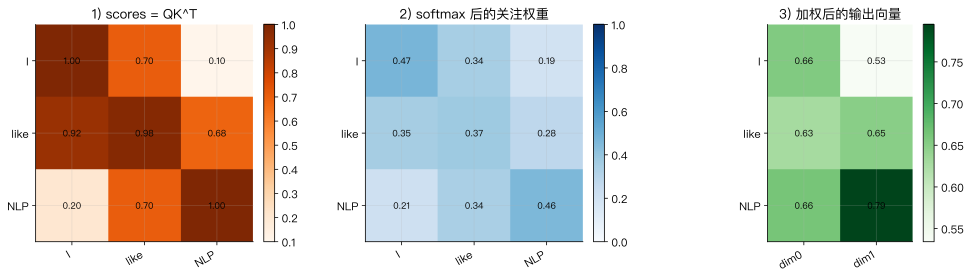

In [8]:
labels = ["I", "like", "NLP"]

# 小到可以手算的 Q/K/V。每行是一个 token，每列是一个维度。
Q = np.array([
    [1.0, 0.0],
    [0.8, 0.6],
    [0.0, 1.0],
])
K = np.array([
    [1.0, 0.2],
    [0.7, 0.7],
    [0.1, 1.0],
])
V = np.array([
    [1.0, 0.0],  # I 提供的信息
    [0.0, 1.0],  # like 提供的信息
    [1.0, 1.0],  # NLP 提供的信息
])

scores = Q @ K.T
weights = softmax_np(scores, axis=-1)
outputs = weights @ V

np.set_printoptions(precision=3, suppress=True)
print("Step 1: scores = Q @ K.T")
print(scores)
print("\nStep 2: attention weights = softmax(scores)；每行和应为 1")
print(weights)
print("row sums:", weights.sum(axis=1))
print("\nStep 3: output = weights @ V")
print(outputs)
assert np.allclose(weights.sum(axis=1), 1.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
show_matrix(scores, labels, labels, "1) scores = QK^T", cmap="Oranges", ax=axes[0])
show_matrix(weights, labels, labels, "2) softmax 后的关注权重", cmap="Blues", vmin=0, vmax=1, ax=axes[1])
show_matrix(outputs, labels, ["dim0", "dim1"], "3) 加权后的输出向量", cmap="Greens", ax=axes[2])
plt.tight_layout()
plt.show()

### 3.1 Q/K/V 从哪里来：三个线性投影

上面为了讲清楚流程，直接手写了 Q、K、V 三个矩阵。真实 Transformer 里，它们**都是同一份 token 向量经过三个不同线性层投影出来的**：

$$
Q = X W_Q,\quad K = X W_K,\quad V = X W_V
$$

- `X ∈ R^(T × d_model)`：token embedding + 位置编码得到的输入序列（第 2 章讲过）。
- `W_Q, W_K, W_V ∈ R^(d_model × d_k)`：三个**可训练**的线性投影矩阵。
- `Q, K, V ∈ R^(T × d_k)`：分别是每个 token 的"查询 / 键 / 值"。

**关键理解**：同一个 token 会同时扮演三种角色——
- 作为 `q_i`：向别人打听（"我要找什么"）
- 作为 `k_j`：被别人打听时提供索引（"我是什么"）
- 作为 `v_j`：真正被读走的内容（"我贡献什么"）

三种角色**共享同一个输入 `x_i`**，但通过三个不同投影解耦，让模型可以在训练中**自己学会**每种角色应该编码什么信息。第 5 章的 multi-head 会把 `W_Q/W_K/W_V` 复制 H 份，得到不同头看不同关系。

In [9]:
# 用一段小 embedding 演示 Q/K/V 是怎么算出来的
torch.manual_seed(0)

T, d_model, d_k = 3, 8, 4
x = torch.randn(T, d_model)              # 一段 3 token 的输入向量

W_Q = torch.randn(d_model, d_k) * 0.5
W_K = torch.randn(d_model, d_k) * 0.5
W_V = torch.randn(d_model, d_k) * 0.5

Q = x @ W_Q
K = x @ W_K
V = x @ W_V

print(f"x shape:   {tuple(x.shape)}  (T={T}, d_model={d_model})")
print(f"W_Q shape: {tuple(W_Q.shape)}  (d_model={d_model} -> d_k={d_k})")
print(f"Q shape:   {tuple(Q.shape)}   (T={T}, d_k={d_k})")
print(f"K shape:   {tuple(K.shape)}")
print(f"V shape:   {tuple(V.shape)}")
print()
print("Q/K/V 三个矩阵形状完全一致, 但因为投影矩阵不同, 内容各异。")
print("训练时 W_Q, W_K, W_V 会被梯度下降学出来, 让 attention 学到有用的关注模式。")

assert Q.shape == K.shape == V.shape == (T, d_k)

x shape:   (3, 8)  (T=3, d_model=8)
W_Q shape: (8, 4)  (d_model=8 -> d_k=4)
Q shape:   (3, 4)   (T=3, d_k=4)
K shape:   (3, 4)
V shape:   (3, 4)

Q/K/V 三个矩阵形状完全一致, 但因为投影矩阵不同, 内容各异。
训练时 W_Q, W_K, W_V 会被梯度下降学出来, 让 attention 学到有用的关注模式。


现在你可以把第 3 章开头的手算 Q/K/V 重新理解为：**W_Q/W_K/W_V 是"学出来"的**，我们前面只是跳过了这一步、直接给了结果。回到那张三步骤图，就能理解为什么"训练"能改变 attention 关注哪里：本质就是通过反向传播调整这三个投影矩阵。

## 4 · Scaled Dot-product Attention：为什么要除以 `sqrt(d_k)`

原版 attention 公式是：

$$
Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

符号含义：

- `Q ∈ R^(T_q × d_k)`：所有 query 排成的矩阵。
- `K ∈ R^(T_k × d_k)`：所有 key 排成的矩阵。
- `V ∈ R^(T_k × d_v)`：所有 value 排成的矩阵。
- `QK^T`：每个 query 对每个 key 的打分矩阵。
- `d_k`：query/key 的维度。
- `sqrt(d_k)`：缩放因子，让分数的尺度更稳定。

为什么要缩放？如果 `q` 和 `k` 的每个元素方差差不多是 1，那么点积 `q · k` 是 `d_k` 个随机项相加，方差会随 `d_k` 变大。分数太大时，softmax 会变得过于尖锐，梯度变小，训练不稳定。

### 4.1 先手算一组小数字

在跑实验之前，先用两组极端的分数手算 softmax，直观感受"分数尺度"如何改变分布。

假设有 3 个 key，query 对它们的原始点积分数是 `[10, 8, 2]`：

- **不缩放**：softmax(`[10, 8, 2]`)。因为 10 比 8 大 2、比 2 大 8，指数放大后几乎全部概率集中到第一个。
- **除以 `sqrt(d_k)`**（设 `d_k=64`，`sqrt(64)=8`）：分数变成 `[1.25, 1.0, 0.25]`，softmax 后分布平缓得多。

分布越尖锐（接近 one-hot），softmax 对输入的梯度越接近 0（因为 `∂softmax/∂score` 在饱和区趋近 0），反向传播时这一层几乎学不动。缩放就是把分数拉回一个"softmax 还有梯度"的区间。

In [10]:
scores_raw = np.array([10.0, 8.0, 2.0])
d_k = 64
scores_scaled = scores_raw / math.sqrt(d_k)

p_raw = softmax_np(scores_raw)
p_scaled = softmax_np(scores_scaled)

print("原始分数      :", scores_raw.tolist())
print("softmax(原始) :", np.round(p_raw, 4).tolist(), " -> 最大概率", round(p_raw.max(), 4))
print()
print(f"缩放后 (/{int(math.sqrt(d_k))}) :", np.round(scores_scaled, 4).tolist())
print("softmax(缩放) :", np.round(p_scaled, 4).tolist(), " -> 最大概率", round(p_scaled.max(), 4))
print()
print("观察：同一组相对大小的分数，缩放后 softmax 明显更平缓，")
print("保留了'次优 key 也有一定权重'的信息，梯度也不会因为过度饱和而消失。")

assert p_raw.max() > p_scaled.max()  # 不缩放更尖锐

原始分数      : [10.0, 8.0, 2.0]
softmax(原始) : [0.8805, 0.1192, 0.0003]  -> 最大概率 0.8805

缩放后 (/8) : [1.25, 1.0, 0.25]
softmax(缩放) : [0.4658, 0.3628, 0.1714]  -> 最大概率 0.4658

观察：同一组相对大小的分数，缩放后 softmax 明显更平缓，
保留了'次优 key 也有一定权重'的信息，梯度也不会因为过度饱和而消失。


### 4.2 用实验验证：维度越大越需要缩放

手算只看了一组固定分数。下面用随机向量做统计实验：让 `d_k` 从 4 涨到 256，看点积分数的标准差和 softmax 熵怎么变化。

d_k | raw score std | scaled score std | raw softmax entropy | scaled entropy
  4 |         2.007 |            1.003 |               2.268 |          3.032
 16 |         4.033 |            1.008 |               1.134 |          3.020
 64 |         8.010 |            1.001 |               0.447 |          3.011
256 |        16.013 |            1.001 |               0.253 |          3.016

规律：raw score std 大致随 sqrt(d_k) 增长，缩放后 std 稳定在 1 附近；
对应地，未缩放的 softmax 熵随 d_k 增大而骤降（越来越尖锐），缩放后保持平稳。


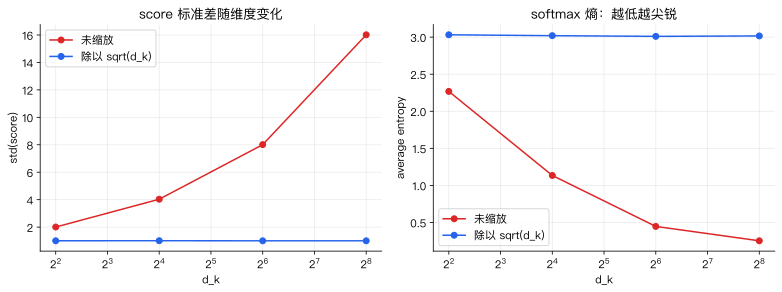

In [11]:
def entropy(p, axis=-1):
    p = np.asarray(p)
    return -(p * np.log(p + 1e-12)).sum(axis=axis)

dims = [4, 16, 64, 256]
n_keys = 32
records = []

for d in dims:
    q = rng.normal(size=(512, d))
    k = rng.normal(size=(512, n_keys, d))
    raw_scores = np.einsum("bd,bkd->bk", q, k)
    scaled_scores = raw_scores / math.sqrt(d)
    raw_p = softmax_np(raw_scores, axis=-1)
    scaled_p = softmax_np(scaled_scores, axis=-1)
    records.append((d, raw_scores.std(), scaled_scores.std(), entropy(raw_p).mean(), entropy(scaled_p).mean()))

print("d_k | raw score std | scaled score std | raw softmax entropy | scaled entropy")
for row in records:
    print(f"{row[0]:>3} | {row[1]:>13.3f} | {row[2]:>16.3f} | {row[3]:>19.3f} | {row[4]:>14.3f}")
print()
print("规律：raw score std 大致随 sqrt(d_k) 增长，缩放后 std 稳定在 1 附近；")
print("对应地，未缩放的 softmax 熵随 d_k 增大而骤降（越来越尖锐），缩放后保持平稳。")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(dims, [r[1] for r in records], "o-", label="未缩放", color=COLORS["red"])
axes[0].plot(dims, [r[2] for r in records], "o-", label="除以 sqrt(d_k)", color=COLORS["blue"])
axes[0].set_xscale("log", base=2)
axes[0].set_title("score 标准差随维度变化")
axes[0].set_xlabel("d_k")
axes[0].set_ylabel("std(score)")
axes[0].legend()

axes[1].plot(dims, [r[3] for r in records], "o-", label="未缩放", color=COLORS["red"])
axes[1].plot(dims, [r[4] for r in records], "o-", label="除以 sqrt(d_k)", color=COLORS["blue"])
axes[1].set_xscale("log", base=2)
axes[1].set_title("softmax 熵：越低越尖锐")
axes[1].set_xlabel("d_k")
axes[1].set_ylabel("average entropy")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5 · Multi-head Attention：为什么要分多个头

一个 attention head 只能用一套 `W_Q`, `W_K`, `W_V` 学一种“看谁”的方式。多头注意力把 `d_model` 切成 `h` 个小空间，让不同 head 同时关注不同关系。

公式：

$$
head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)
$$

$$
MultiHead(Q,K,V) = Concat(head_1,\dots,head_h)W^O
$$

符号含义：

- `h`：head 数量。
- `W_i^Q, W_i^K, W_i^V`：第 `i` 个 head 自己的线性投影。
- `Concat(...)`：把所有 head 的输出拼回 `d_model` 维。
- `W^O`：输出投影，让不同 head 的信息重新混合。

实际含义：一个 head 可以看“主谓关系”，另一个 head 可以看“相邻词”，再一个 head 可以看“长距离依赖”。模型不需要我们手写规则，而是在训练中自己分工。

In [12]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x):
        # x: [B, T, D] -> [B, H, T, Dh]
        B, T, D = x.shape
        return x.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

    def _merge_heads(self, x):
        # x: [B, H, T, Dh] -> [B, T, D]
        B, H, T, Dh = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, H * Dh)

    def forward(self, query, key, value, mask=None, need_weights=False):
        q = self._split_heads(self.q_proj(query))
        k = self._split_heads(self.k_proj(key))
        v = self._split_heads(self.v_proj(value))

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if mask is not None:
            # mask: True 表示允许看见，False 表示必须遮住
            scores = scores.masked_fill(~mask, -1e9)
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        out = self.out_proj(self._merge_heads(out))
        if need_weights:
            return out, attn
        return out

x = torch.randn(2, 5, 32)
mha = MultiHeadAttention(d_model=32, num_heads=4)
out, attn = mha(x, x, x, need_weights=True)
print("input shape :", tuple(x.shape), " = [batch, seq_len, d_model]")
print("output shape:", tuple(out.shape))
print("attn shape  :", tuple(attn.shape), " = [batch, heads, query_len, key_len]")
assert out.shape == x.shape
assert attn.shape == (2, 4, 5, 5)
assert torch.allclose(attn.sum(dim=-1), torch.ones_like(attn.sum(dim=-1)), atol=1e-5)

input shape : (2, 5, 32)  = [batch, seq_len, d_model]
output shape: (2, 5, 32)
attn shape  : (2, 4, 5, 5)  = [batch, heads, query_len, key_len]


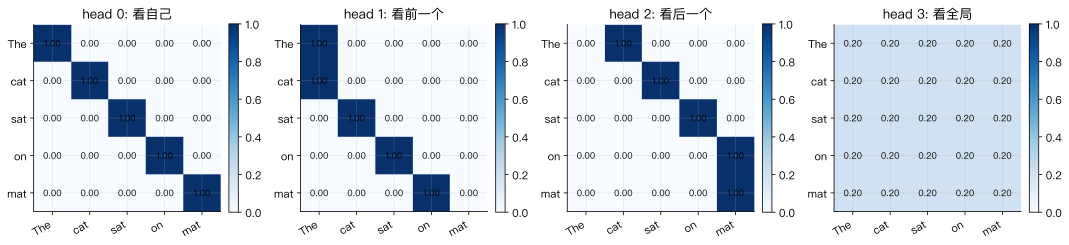

这些是教学用的理想化 head。真实模型会在训练中自己学出类似但更复杂的模式。


In [13]:
head_names = ["head 0: 看自己", "head 1: 看前一个", "head 2: 看后一个", "head 3: 看全局"]
toy_tokens = ["The", "cat", "sat", "on", "mat"]
T = len(toy_tokens)
patterns = []
patterns.append(np.eye(T))
patterns.append(np.vstack([np.eye(T)[max(i - 1, 0)] for i in range(T)]))
patterns.append(np.vstack([np.eye(T)[min(i + 1, T - 1)] for i in range(T)]))
patterns.append(np.ones((T, T)) / T)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, mat, name in zip(axes, patterns, head_names):
    show_matrix(mat, toy_tokens, toy_tokens, name, cmap="Blues", vmin=0, vmax=1, ax=ax)
plt.tight_layout()
plt.show()

print("这些是教学用的理想化 head。真实模型会在训练中自己学出类似但更复杂的模式。")

### 5.1 [进阶] MHA → MQA → GQA：为什么现代 LLM 要共享 K/V

> 本节属于横向进阶阅读，可跳过。第 14 章速查表会回链到这里。

MHA（Multi-Head Attention）里，每个 head 都有自己的 `W_Q, W_K, W_V`。这带来一个**推理时的显存问题**：

**单层 KV cache 的显存开销**（13.3 节会给出完整跨层公式）：

$$
\text{KV cache size (per layer)} = 2 \cdot B \cdot T \cdot H \cdot d_k \cdot \text{bytes}
$$

- `2`：K 和 V 各存一份。
- `B`：batch size。
- `T`：序列长度。
- `H`：head 数量。
- `d_k`：每个 head 的维度。

真实模型有 `L` 层，总显存要再乘 `L`（例如 LLaMA-3-70B 有 80 层）。推理长上下文时 `T` 很大（32k、128k），`H · d_k = d_model` 通常也很大（4096+），KV cache 会**吃掉大部分显存**，甚至超过模型权重本身。

**观察**：真正需要多样性的其实是 `Q`（每个 head 用不同的方式"查"），K 和 V 更像是"共享的记忆"，可以让多个 head 共用。这就是 MQA / GQA 的动机。

**三种方案对比**：

| 方案 | Q head 数 | K/V head 数 | KV cache | 出处 |
|---|---|---|---|---|
| MHA（Multi-Head） | H | H | 100% 基线 | 原版 Transformer |
| **MQA**（Multi-Query） | H | **1** | 1/H | Shazeer 2019 |
| **GQA**（Grouped-Query） | H | H/g（g 组） | g/H | Ainslie et al. 2023 |

- **MQA**：所有 head 共用**同一份** K/V，KV cache 直接压到 1/H。极致省显存，但表达能力有损失。
- **GQA**：折中方案，把 H 个 Q head 分成 g 组，每组共用一份 K/V。`g = H` 就是 MHA，`g = 1` 就是 MQA。

**代表模型**：
- MHA：BERT, GPT-2, GPT-3, 原版 LLaMA-1
- MQA：PaLM, Falcon
- **GQA**：LLaMA-2 (70B), LLaMA-3, Qwen-2, Mistral, DeepSeek —— 现代 LLM 默认选择

一个典型配置：LLaMA-3-70B 用 `H=64` 个 Q head、`g=8` 组，也就是 8 份 K/V。相比 MHA 的 64 份 K/V，**KV cache 直接压到 1/8**。

In [14]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_kv_heads):
        super().__init__()
        assert num_heads % num_kv_heads == 0, "num_heads 必须能被 num_kv_heads 整除"
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.num_kv_heads = num_kv_heads
        self.group_size = num_heads // num_kv_heads  # 每份 K/V 被多少个 Q head 共享
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, num_heads * self.head_dim, bias=False)
        self.k_proj = nn.Linear(d_model, num_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(d_model, num_kv_heads * self.head_dim, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        q = self.q_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)

        # 关键：把 K/V 沿 head 维复制 group_size 份，让 shape 和 Q 对齐
        k = k.repeat_interleave(self.group_size, dim=1)
        v = v.repeat_interleave(self.group_size, dim=1)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, v).transpose(1, 2).contiguous().view(B, T, D)
        return self.out_proj(out)


d_model, num_heads = 32, 8
x = torch.randn(2, 5, d_model)

for kv in [8, 4, 1]:
    m = GroupedQueryAttention(d_model, num_heads=num_heads, num_kv_heads=kv)
    n_params = sum(p.numel() for p in m.parameters())
    name = "MHA" if kv == num_heads else ("MQA" if kv == 1 else f"GQA(g={kv})")
    print(f"{name:>10}  num_kv_heads={kv}  params={n_params:>5}  output shape={tuple(m(x).shape)}")

       MHA  num_kv_heads=8  params= 4096  output shape=(2, 5, 32)
  GQA(g=4)  num_kv_heads=4  params= 3072  output shape=(2, 5, 32)
       MQA  num_kv_heads=1  params= 2304  output shape=(2, 5, 32)


观察参数量：**Q 投影的参数量不变**，变的只是 K/V 投影。这解释了为什么 GQA/MQA 主要影响 KV cache（推理显存），对模型总参数量影响很小。

**一句话记忆**：**MHA 是"每头独立"，MQA 是"全部共享"，GQA 是"分组共享"，选谁看你更在乎表达能力还是推理显存。**

## 6 · Mask：控制“哪些位置允许被看见”

Attention 默认每个 query 都能看见所有 key。但实际任务里有三种常见限制：

1. **Padding mask**：`<pad>` 是补齐符，不是真实 token，不能被关注。
2. **Causal mask**：语言模型预测下一个词时，当前位置不能偷看未来 token。
3. **Cross-attention mask**：decoder 看 encoder 输出时，也要避开 source 里的 `<pad>`。

我们约定 mask 的布尔含义：

- `True`：允许看见。
- `False`：必须遮住，score 会被设成一个很小的数，softmax 后概率接近 0。

一个容易混淆的细节：这里的 padding mask shape 是 `[B, 1, 1, T_k]`，它主要控制 **key 侧**哪些位置不可见。也就是说：

- `<pad>` 作为 key/value 时，不应该被任何 query 关注。
- `<pad>` 作为 query 时，通常仍会产生一行输出；训练 loss 用 `ignore_index=PAD` 忽略这些位置。
- 如果某一行 query 的所有 key 都被遮住，softmax 可能出现 NaN，所以工程里要避免“全遮行”，或在实现中做特殊处理。

src padding mask shape: (1, 1, 1, 5)
tgt causal mask shape : (1, 1, 5, 5)
combined tgt mask shape: (1, 1, 5, 5)


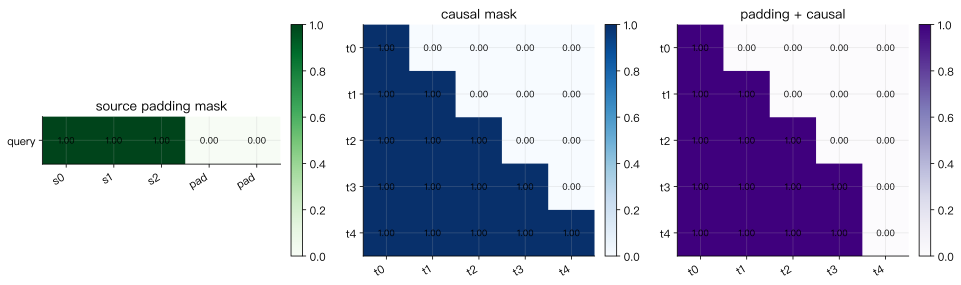

In [15]:
PAD_ID = 0

def make_padding_mask(seq, pad_id=PAD_ID):
    # seq: [B, T] -> [B, 1, 1, T]，可广播到 [B, H, Tq, T]
    return (seq != pad_id).unsqueeze(1).unsqueeze(2)

def make_causal_mask(size, device=None):
    # [1, 1, T, T]
    return torch.tril(torch.ones(size, size, dtype=torch.bool, device=device)).unsqueeze(0).unsqueeze(0)

src = torch.tensor([[4, 5, 6, 0, 0]])
tgt = torch.tensor([[1, 7, 8, 9, 0]])
src_pad_mask = make_padding_mask(src)
tgt_pad_mask = make_padding_mask(tgt)
tgt_causal_mask = make_causal_mask(tgt.size(1))
tgt_self_mask = tgt_pad_mask & tgt_causal_mask

print("src padding mask shape:", tuple(src_pad_mask.shape))
print("tgt causal mask shape :", tuple(tgt_causal_mask.shape))
print("combined tgt mask shape:", tuple(tgt_self_mask.shape))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
show_matrix(src_pad_mask[0, 0].numpy(), ["query"], ["s0", "s1", "s2", "pad", "pad"],
            "source padding mask", cmap="Greens", vmin=0, vmax=1, ax=axes[0])
show_matrix(tgt_causal_mask[0, 0].numpy(), [f"t{i}" for i in range(5)], [f"t{i}" for i in range(5)],
            "causal mask", cmap="Blues", vmin=0, vmax=1, ax=axes[1])
show_matrix(tgt_self_mask[0, 0].numpy(), [f"t{i}" for i in range(5)], [f"t{i}" for i in range(5)],
            "padding + causal", cmap="Purples", vmin=0, vmax=1, ax=axes[2])
plt.tight_layout()
plt.show()

assert src_pad_mask.shape == (1, 1, 1, 5)
assert tgt_self_mask.shape == (1, 1, 5, 5)

### 6.1 Bool mask、additive mask 和 PyTorch API 差异

不同库对 mask 的约定并不完全一致，这是工程里很常见的坑。

| 写法 | 本教程约定 | 常见 PyTorch API 中可能的含义 |
|---|---|---|
| bool mask | `True=可见`, `False=遮住` | 有些 API 用 `True=遮住` |
| additive mask | 可见位置加 `0`，遮住位置加 `-inf` 或极小值 | HuggingFace 中常见 |
| padding mask | `[B,1,1,T_k]`，遮 key/value | `nn.MultiheadAttention` 常用 `[B,T_k]` |
| causal mask | `[1,1,T,T]` 下三角 | 有些 API 支持 `is_causal=True` 自动生成 |

所以迁移代码时不要只看变量名叫 `mask`，要确认三件事：shape、True/False 含义、它加到 score 前还是后。

In [16]:
if HAS_WIDGETS:
    def show_mask(seq_len=6, pad_from=4, mask_type="causal + padding"):
        seq = torch.tensor([[1 if i < pad_from else 0 for i in range(seq_len)]])
        pad = make_padding_mask(seq)
        causal = make_causal_mask(seq_len)
        if mask_type == "padding":
            mat = pad[0, 0].repeat(seq_len, 1).numpy()
        elif mask_type == "causal":
            mat = causal[0, 0].numpy()
        else:
            mat = (pad & causal)[0, 0].numpy()
        show_matrix(mat, [f"q{i}" for i in range(seq_len)], [f"k{i}" for i in range(seq_len)],
                    f"{mask_type}: True=可见", cmap="Greens", vmin=0, vmax=1)
        plt.show()

    interact(
        show_mask,
        seq_len=IntSlider(value=6, min=3, max=10, step=1, description="seq_len"),
        pad_from=IntSlider(value=4, min=1, max=10, step=1, description="pad_from"),
        mask_type=Dropdown(options=["padding", "causal", "causal + padding"], value="causal + padding"),
    )
else:
    print("当前环境没有 ipywidgets，已跳过交互控件。")

interactive(children=(IntSlider(value=6, description='seq_len', max=10, min=3), IntSlider(value=4, description…

## 7 · Transformer Block：Attention 之外还缺什么

单独的 attention 还不是 Transformer block。一个可训练、可堆叠的 block 至少需要三类组件：

| 组件 | 要解决的问题 | 工程含义 |
|---|---|---|
| Residual connection | 深层网络梯度难传 | `x + sublayer(x)` 保留原信息通道 |
| LayerNorm | 每层激活尺度漂移 | 让每个 token 向量内部归一化 |
| Feed Forward Network | attention 只做 token 间混合 | FFN 对每个 token 独立做非线性变换 |

这里使用 **Pre-Norm** 写法：先 LayerNorm，再进入子层。它比原论文的 Post-Norm 更适合稳定训练较深模型。

### 7.1 论文原版 vs 本教程工程写法

本教程讲的是原版 Transformer 的结构主线，但代码不是 2017 论文的逐字复刻。为了让 toy notebook 更稳定、更贴近现代 PyTorch 实践，我们采用了几个常见工程变体：

| 设计点 | 2017 原论文常见写法 | 本教程写法 | 为什么这样做 |
|---|---|---|---|
| Normalization | Post-Norm：`LayerNorm(x + sublayer(x))` | Pre-Norm：`x + sublayer(LayerNorm(x))` | 深层训练更稳定，现代实现常见 |
| FFN activation | ReLU | GELU | BERT/GPT 系列常见，曲线更平滑 |
| Positional encoding | sinusoidal | sinusoidal | 保留原论文核心设计 |
| Attention 类型 | MHA | MHA | 保留原论文核心设计 |

更现代的大模型还会继续改：RoPE/RMSNorm/SwiGLU/MQA/GQA 等。这些不是本章重点，但你要知道“Transformer 主线”和“某个工程实现细节”不是一回事。

### 7.2 [进阶] 归一化的演进：从 LayerNorm 到 RMSNorm

> 本节起到 **7.4** 属于横向进阶阅读。第一次通读可以跳过，直接进入 7.5（或第 8 章的 encoder-decoder 组装）。第 14 章末尾的速查表会回链到这里。

**Normalization 是 Transformer 每层都要做的事**，直接影响训练稳定性。它从 2016 到现在也换了好几代。先给一条时间线：

| 年份 | 方案 | 出处 | 一句话动机 |
|---|---|---|---|
| 2015 | BatchNorm | Ioffe & Szegedy | 沿 batch 维做归一化；序列长度可变时不好用 |
| 2016 | LayerNorm | Ba et al. | 沿特征维、逐样本归一化；Transformer 原版就用它 |
| 2019 | RMSNorm | Zhang & Sennrich | LayerNorm 去掉“减均值”和 bias，更快、参数更少 |
| 2022+ | DeepNorm / ScaleNorm 等 | Microsoft 等 | 极深 Transformer 的稳定性方案，工业界用得少 |

**顺便讲清楚一个常见困惑：归一化 ≠ 正则化。**

- 归一化改变的是**前向传播**（把激活压回稳定尺度），loss 表达式不变。
- 正则化（L2、Dropout、Label Smoothing）改变的是**目标函数或前向的随机性**，用来抑制过拟合。

两者在训练脚本里经常并列出现，但作用完全不同。

### 7.3 LayerNorm vs RMSNorm：公式和参数对比

**LayerNorm**（Ba et al. 2016）：

$$
\text{LN}(x) = \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}} \odot \gamma + \beta
$$

- `x ∈ R^d`：一个 token 的隐藏向量。
- `μ = mean(x)`、`σ² = var(x)`：在**特征维**上算的均值和方差（不是 batch 维）。
- `γ, β ∈ R^d`：可训练的 scale 和 shift。
- 做了两件事：**re-centering**（减均值）+ **re-scaling**（除以标准差）。

**RMSNorm**（Zhang & Sennrich 2019）：

$$
\text{RMSNorm}(x) = \frac{x}{\sqrt{\text{mean}(x^2) + \varepsilon}} \odot \gamma
$$

- 只保留 **re-scaling**，去掉 re-centering。
- 分母是 RMS（Root Mean Square）：`sqrt(mean(x²))`。
- 只有 `γ`，**没有 `β`**。

**关键结论**：作者实验发现 LayerNorm 里“减均值”这一步几乎没贡献，真正稳定训练的是“除以尺度”。去掉它后：

| 对比项 | LayerNorm | RMSNorm |
|---|---|---|
| 计算量 | 均值 + 方差 | 只有平方均值 |
| 参数量（每层） | `2d`（γ 和 β） | `d`（只有 γ） |
| 数学操作 | re-center + re-scale | 只 re-scale |
| 效果 | 基线 | 几乎持平，训练稍快 |

**实际采用情况**：

- **LayerNorm**：BERT、GPT-2/3、T5、BLOOM、OPT（2017–2022 主流）。
- **RMSNorm**：LLaMA 1/2/3、Qwen、Mistral、DeepSeek、GLM、Gemma、Baichuan（2023 后几乎所有开源 LLM 的默认选择）。

配合前面讲过的 Pre-Norm 位置，现代 LLM 的标配组合是：**Pre-Norm + RMSNorm**。

### 7.4 手算：LayerNorm 和 RMSNorm 差在哪一步

下面用同一个向量走两遍，看看两者的中间量和输出到底不同在哪里。

In [17]:
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        # x: [..., d_model]
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return self.gamma * x / rms


x = torch.tensor([1.0, 2.0, 3.0, 4.0])
d = x.numel()

mu = x.mean()
var = x.var(unbiased=False)
ln_out = (x - mu) / torch.sqrt(var + 1e-6)

rms = torch.sqrt((x ** 2).mean() + 1e-6)
rn_out = x / rms

print(f"input           : {x.tolist()}")
print(f"LayerNorm  mean : {mu.item():+.4f}")
print(f"LayerNorm  std  : {torch.sqrt(var).item():+.4f}")
print(f"LayerNorm  out  : {[round(v, 4) for v in ln_out.tolist()]}")
print(f"                  (均值为 0, 标准差为 1)")
print()
print(f"RMSNorm    rms  : {rms.item():+.4f}")
print(f"RMSNorm    out  : {[round(v, 4) for v in rn_out.tolist()]}")
print(f"                  (均值不为 0, 只保证 RMS = 1)")

assert torch.isclose(ln_out.mean(), torch.tensor(0.0), atol=1e-5)
# 注意：RMSNorm 输出的 RMS 不会精确等于 1，而是 sqrt(mean(x^2) / (mean(x^2)+eps))。
# 这里 x 尺度远大于 eps=1e-6，所以 RMS 非常接近 1；atol 稍放宽即可。
assert torch.isclose((rn_out ** 2).mean().sqrt(), torch.tensor(1.0), atol=1e-3)

input           : [1.0, 2.0, 3.0, 4.0]
LayerNorm  mean : +2.5000
LayerNorm  std  : +1.1180
LayerNorm  out  : [-1.3416, -0.4472, 0.4472, 1.3416]
                  (均值为 0, 标准差为 1)

RMSNorm    rms  : +2.7386
RMSNorm    out  : [0.3651, 0.7303, 1.0954, 1.4606]
                  (均值不为 0, 只保证 RMS = 1)


观察到的关键差别：

- **LayerNorm 输出的均值一定是 0**，因为它先减了均值。
- **RMSNorm 输出的均值不一定是 0**，它只保证 RMS = 1；输入本身偏正/偏负会被保留下来。

这也是 RMSNorm 参数少一个 `β` 的原因：既然不 re-center，就不需要用 `β` 再把中心加回来。

小结：**LayerNorm → RMSNorm 是“做减法”的演进——去掉贡献不大的一步，换来更快的计算和更少的参数**。这条思路在现代 LLM 里非常常见：Attention 用 MQA/GQA 去掉多余的 K/V 投影，FFN 用 SwiGLU 换掉普通 MLP 都属于同一类工程收敛。

### 7.5 [进阶] FFN 激活函数的演进：ReLU → GELU → SwiGLU

> 本节起到 **7.8** 属于横向进阶阅读。第一次通读可以跳过，直接进入第 8 章。第 14 章末尾的速查表会回链到这里。

Transformer 里 attention 负责 token 之间的信息交换，**FFN（Feed Forward Network）负责每个 token 独立做一次非线性变换**。原论文的 FFN 长这样：

$$
\text{FFN}(x) = \text{ReLU}(xW_1 + b_1) W_2 + b_2
$$

- `x ∈ R^d`：一个 token 的隐藏向量（`d = d_model`）。
- `W_1 ∈ R^{d × d_ff}`：升维矩阵，通常 `d_ff = 4d`。
- `W_2 ∈ R^{d_ff × d}`：降维矩阵。
- `ReLU`：激活函数。

**时间线**：

| 年份 | 激活 | 出处 | 一句话动机 |
|---|---|---|---|
| 2016 | GELU | Hendrycks & Gimpel (arXiv 2016) | 平滑版 ReLU，后来 BERT/GPT-2 起成为主流 |
| 2017 | ReLU（原版 Transformer 采用） | Vaswani et al. | 结构简单快，原版 FFN 默认选择 |
| 2017 | Swish / SiLU | Ramachandran et al. (Swish) / Elfwing et al. (SiLU) | `x · sigmoid(x)`，与 GELU 形状几乎重合，早期未被 Transformer 采用 |
| 2020 | GLU 家族（GLU/GeGLU/SwiGLU） | Shazeer, *GLU Variants Improve Transformer* | 用"门控"替代单纯的激活，效果稳定更好 |
| 2023+ | SwiGLU 成为默认 | LLaMA / PaLM / Qwen / Mistral | 现代 LLM 几乎全部采用 |

> 注：GELU 的提出（2016）其实早于原版 Transformer 用的 ReLU 场景（2017），只是它在 BERT/GPT-2（2018–2019）之后才真正流行。年份指论文提出时间，不代表被 Transformer 采用的时间。

### 7.6 各激活函数的公式和曲线

**ReLU**：
$$
\text{ReLU}(x) = \max(0, x)
$$
简单直接，`x ≤ 0` 时梯度为 0（"dying ReLU"），`x > 0` 时不衰减。

**GELU**（Gaussian Error Linear Unit）：
$$
\text{GELU}(x) = x \cdot \Phi(x)
$$
其中 `Φ(x)` 是标准正态分布的 CDF。直觉：不像 ReLU 硬切成 0，而是**按“这个值有多可能是正的”给一个软加权**。曲线在 0 附近平滑，负值不完全归零。

**SiLU / Swish**：
$$
\text{SiLU}(x) = x \cdot \sigma(x),\quad \sigma(x) = \frac{1}{1 + e^{-x}}
$$
和 GELU 曲线极为接近，但计算更简单（不用 CDF 近似）。在 SwiGLU 里用的就是 SiLU。

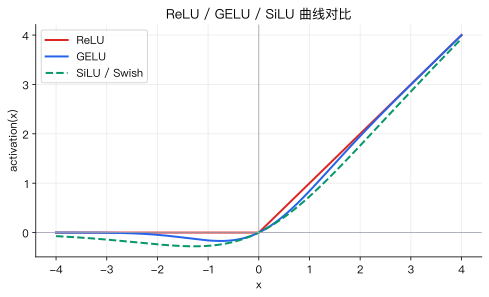

 ReLU(-1) = +0.0000    ReLU(0.5) = +0.5000    ReLU(2) = +2.0000
 GELU(-1) = -0.1588    GELU(0.5) = +0.3457    GELU(2) = +1.9546
 SiLU(-1) = -0.2689    SiLU(0.5) = +0.3112    SiLU(2) = +1.7616


In [18]:
xs = np.linspace(-4, 4, 400)

def relu(x): return np.maximum(0, x)
def gelu(x): return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x ** 3)))
def silu(x): return x / (1 + np.exp(-x))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(xs, relu(xs), label="ReLU",  color=COLORS["red"],    lw=2)
ax.plot(xs, gelu(xs), label="GELU",  color=COLORS["blue"],   lw=2)
ax.plot(xs, silu(xs), label="SiLU / Swish", color=COLORS["green"], lw=2, linestyle="--")
ax.axhline(0, color="#9ca3af", lw=0.8)
ax.axvline(0, color="#9ca3af", lw=0.8)
ax.set_title("ReLU / GELU / SiLU 曲线对比")
ax.set_xlabel("x"); ax.set_ylabel("activation(x)")
ax.legend()
plt.show()

for name, f in [("ReLU", relu), ("GELU", gelu), ("SiLU", silu)]:
    print(f"{name:>5}(-1) = {f(-1):+.4f}   {name:>5}(0.5) = {f(0.5):+.4f}   {name:>5}(2) = {f(2):+.4f}")

观察：

- **ReLU 在 `x = -1` 处直接是 0**，负半轴没有梯度。
- **GELU(-1) ≈ -0.16、SiLU(-1) ≈ -0.27**（见上方代码输出），两者都把负值“压小”而不是清零，因此负半轴仍有梯度。
- GELU 和 SiLU 曲线在整体形状上很接近，工程上常互换；但在同一点上数值并不完全相等（如上，SiLU 在负值处压得比 GELU 更狠一点）。

### 7.7 GLU：从“激活函数”到“门控结构”

**GLU（Gated Linear Unit）**改变的不是激活函数本身，而是 FFN 的**结构**。原始 FFN 只有一路升维：

$$
\text{FFN}(x) = \phi(xW_1) W_2
$$

GLU 把升维分成**两路**，一路做“门”，一路做“值”，逐元素相乘：

$$
\text{GLU}(x) = \big(\phi(xW_1)\big) \odot (xV)
$$

- `W_1, V ∈ R^{d × d_ff}`：两组升维矩阵。
- `φ`：激活函数，决定 GLU 的具体名字。
- `⊙`：逐元素乘。
- 直觉：`φ(xW_1)` 是一个介于 0 到 1（或类似范围）的“开关”，决定 `xV` 里哪些维度被放行。

**命名规则由 `φ` 决定**：

| 名字 | `φ` 是什么 | 出处 |
|---|---|---|
| GLU | `sigmoid` | Dauphin et al. 2017 |
| ReGLU | `ReLU` | Shazeer 2020 |
| GeGLU | `GELU` | Shazeer 2020，PaLM 采用 |
| SwiGLU | `SiLU / Swish` | Shazeer 2020，LLaMA/Qwen/Mistral 采用 |

Shazeer 2020 的对比实验里，**GeGLU 和 SwiGLU 稳定优于 ReLU/GELU 版 FFN**，成为现代 LLM 的默认。

### 7.8 SwiGLU 完整实现：为什么隐藏维从 `4d` 改成 `~2.67d`

SwiGLU 的 FFN 完整形式：

$$
\text{FFN}_{\text{SwiGLU}}(x) = \big(\text{SiLU}(xW_1)\big) \odot (xV) \cdot W_2
$$

**参数量的坑**：普通 FFN 有 `2 · d · d_ff` 参数（`W_1` + `W_2`）；SwiGLU 因为多了一个 `V`，参数量变成 `3 · d · d_ff`。为了保持总参数量和原 FFN 相当，LLaMA 把 `d_ff` 从 `4d` 缩到 **约 `8d/3 ≈ 2.67d`**（并向 128/256 的倍数对齐）：

$$
\text{params}_{\text{SwiGLU}} = 3 \cdot d \cdot \frac{8d}{3} = 8d^2 \approx \text{params}_{\text{ReLU FFN}} = 2 \cdot d \cdot 4d = 8d^2
$$

所以看到 LLaMA/Qwen 的 config 里 `intermediate_size` 不是 `4 × hidden_size`，而是 `~2.67 ×` 时，不是配置错了，是 SwiGLU 的标准做法。

In [19]:
class SwiGLUFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.w_gate = nn.Linear(d_model, d_ff, bias=False)
        self.w_up   = nn.Linear(d_model, d_ff, bias=False)
        self.w_down = nn.Linear(d_ff, d_model, bias=False)

    def forward(self, x):
        # x: [..., d_model]
        return self.w_down(F.silu(self.w_gate(x)) * self.w_up(x))


d_model = 32
d_ff_relu    = 4 * d_model                              # 128
d_ff_swiglu  = int(round(8 * d_model / 3 / 8)) * 8      # 8d/3 对齐到 8 的倍数, d=32 -> 88

ff_relu = nn.Sequential(nn.Linear(d_model, d_ff_relu), nn.ReLU(),
                        nn.Linear(d_ff_relu, d_model))
ff_swiglu = SwiGLUFeedForward(d_model, d_ff_swiglu)

def count(m):
    return sum(p.numel() for p in m.parameters())

x = torch.randn(2, 5, d_model)
print(f"d_model = {d_model}")
print(f"ReLU FFN   d_ff = {d_ff_relu}   params = {count(ff_relu):>6}   output shape = {tuple(ff_relu(x).shape)}")
print(f"SwiGLU FFN d_ff = {d_ff_swiglu}   params = {count(ff_swiglu):>6}   output shape = {tuple(ff_swiglu(x).shape)}")
print()
print("SwiGLU 用 3 个矩阵、但每个更窄，总参数量控制在和 ReLU FFN 相近。")

d_model = 32
ReLU FFN   d_ff = 128   params =   8352   output shape = (2, 5, 32)
SwiGLU FFN d_ff = 88   params =   8448   output shape = (2, 5, 32)

SwiGLU 用 3 个矩阵、但每个更窄，总参数量控制在和 ReLU FFN 相近。


**代表模型对照**：

| 时期 | 模型 | FFN 激活/结构 |
|---|---|---|
| 2017 | 原版 Transformer | ReLU |
| 2018–2020 | BERT / GPT-2 / GPT-3 | GELU |
| 2020 | T5 | ReLU（少数派） |
| 2022 | PaLM | GeGLU |
| 2023+ | LLaMA / Qwen / Mistral / DeepSeek / Gemma | **SwiGLU** |

一句话：**FFN 从“一路激活”走到“两路门控”，激活函数从硬切换到平滑再到门控，主线和位置编码、归一化一样，是持续做减法+加门控的工程收敛过程。**

In [20]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pe = torch.tensor(sinusoidal_encoding(max_len, d_model), dtype=torch.float32).unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [B, T, D]
        return x + self.pe[:, :x.size(1), :]


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        y = self.norm1(x)
        x = x + self.dropout(self.self_attn(y, y, y, mask=src_mask))
        y = self.norm2(x)
        x = x + self.ffn(y)
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, tgt_mask=None, memory_mask=None):
        y = self.norm1(x)
        x = x + self.dropout(self.self_attn(y, y, y, mask=tgt_mask))
        y = self.norm2(x)
        x = x + self.dropout(self.cross_attn(y, memory, memory, mask=memory_mask))
        y = self.norm3(x)
        x = x + self.ffn(y)
        return x


demo_layer = EncoderLayer(d_model=32, num_heads=4, d_ff=64)
demo_x = torch.randn(2, 5, 32)
demo_mask = torch.ones(2, 1, 1, 5, dtype=torch.bool)
demo_y = demo_layer(demo_x, demo_mask)
print("EncoderLayer input :", tuple(demo_x.shape))
print("EncoderLayer output:", tuple(demo_y.shape))
assert demo_y.shape == demo_x.shape

EncoderLayer input : (2, 5, 32)
EncoderLayer output: (2, 5, 32)


## 8 · Encoder、Decoder 与原版 Transformer

原版 Transformer 是 **Encoder-Decoder**：

- Encoder 读入 source 序列，例如英文句子。
- Decoder 一边看已经生成的 target 前缀，一边通过 cross-attention 看 encoder 输出。
- 训练时用 teacher forcing：把正确 target 右移一位喂给 decoder，让它预测下一个 token。

三种 attention 的职责不同：

| 位置 | Q 来自 | K/V 来自 | mask |
|---|---|---|---|
| Encoder self-attention | source | source | padding mask |
| Decoder self-attention | target prefix | target prefix | padding + causal mask |
| Decoder cross-attention | target hidden | encoder memory | source padding mask |

In [21]:
class TinyTransformerSeq2Seq(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=32, num_heads=4,
                 d_ff=96, num_layers=1, dropout=0.1, max_len=64, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model
        self.src_embed = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_id)
        self.tgt_embed = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_id)
        self.pos = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.enc_norm = nn.LayerNorm(d_model)
        self.dec_norm = nn.LayerNorm(d_model)
        self.generator = nn.Linear(d_model, tgt_vocab_size)

    def encode(self, src, src_mask):
        x = self.src_embed(src) * math.sqrt(self.d_model)
        x = self.pos(x)
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return self.enc_norm(x)

    def decode(self, tgt_in, memory, tgt_mask, memory_mask):
        x = self.tgt_embed(tgt_in) * math.sqrt(self.d_model)
        x = self.pos(x)
        for layer in self.decoder_layers:
            x = layer(x, memory, tgt_mask=tgt_mask, memory_mask=memory_mask)
        return self.dec_norm(x)

    def forward(self, src, tgt_in, src_mask, tgt_mask):
        memory = self.encode(src, src_mask)
        dec = self.decode(tgt_in, memory, tgt_mask, src_mask)
        return self.generator(dec)


src_demo = torch.tensor([[3, 4, 5, 0]])
tgt_in_demo = torch.tensor([[1, 6, 7, 0]])
model_demo = TinyTransformerSeq2Seq(src_vocab_size=10, tgt_vocab_size=10)
src_mask_demo = make_padding_mask(src_demo)
tgt_mask_demo = make_padding_mask(tgt_in_demo) & make_causal_mask(tgt_in_demo.size(1))
logits_demo = model_demo(src_demo, tgt_in_demo, src_mask_demo, tgt_mask_demo)
print("src:", tuple(src_demo.shape), "tgt_in:", tuple(tgt_in_demo.shape))
print("logits:", tuple(logits_demo.shape), " = [batch, target_len, target_vocab]")
assert logits_demo.shape == (1, tgt_in_demo.size(1), 10)

src: (1, 4) tgt_in: (1, 4)
logits: (1, 4, 10)  = [batch, target_len, target_vocab]


### 8.1 一张图看清数据流

上面的代码用文字描述了 encoder→decoder→cross-attention 的连接。下面把它画成一张数据流图：**source 走 encoder 变成 memory，target 前缀走 decoder，中间靠 cross-attention 把两条路连起来**。

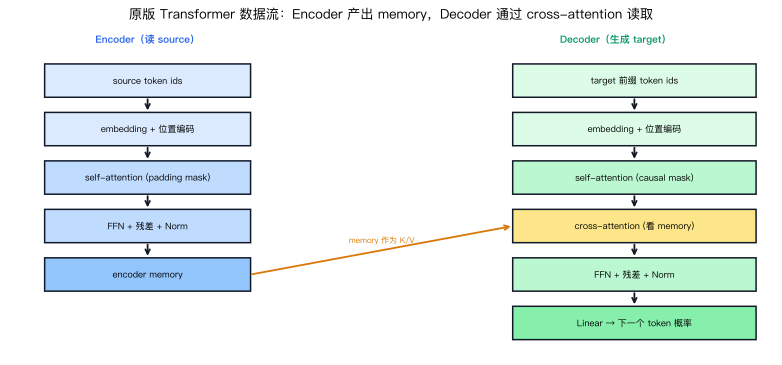

红黄箭头是关键：decoder 的 cross-attention 用自己的 Q 去查 encoder memory 的 K/V，
这就是 source 信息进入 target 生成过程的唯一通道。


In [22]:
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.axis("off")

def box(x, y, w, h, text, color):
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor=COLORS["dark"], lw=1.5, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9, zorder=3)

def arrow(x1, y1, x2, y2, color=COLORS["dark"], text=None):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.8), zorder=1)
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", fontsize=8, color=color)

# ---- Encoder 栈 (左) ----
ax.text(1.5, 5.4, "Encoder（读 source）", ha="center", fontsize=10, color=COLORS["blue"], weight="bold")
box(0.4, 4.5, 2.2, 0.55, "source token ids", "#dbeafe")
box(0.4, 3.7, 2.2, 0.55, "embedding + 位置编码", "#dbeafe")
box(0.4, 2.9, 2.2, 0.55, "self-attention (padding mask)", "#bfdbfe")
box(0.4, 2.1, 2.2, 0.55, "FFN + 残差 + Norm", "#bfdbfe")
box(0.4, 1.3, 2.2, 0.55, "encoder memory", "#93c5fd")
arrow(1.5, 4.5, 1.5, 4.25); arrow(1.5, 3.7, 1.5, 3.45)
arrow(1.5, 2.9, 1.5, 2.65); arrow(1.5, 2.1, 1.5, 1.85)

# ---- Decoder 栈 (右) ----
ax.text(6.5, 5.4, "Decoder（生成 target）", ha="center", fontsize=10, color=COLORS["green"], weight="bold")
box(5.4, 4.5, 2.6, 0.55, "target 前缀 token ids", "#dcfce7")
box(5.4, 3.7, 2.6, 0.55, "embedding + 位置编码", "#dcfce7")
box(5.4, 2.9, 2.6, 0.55, "self-attention (causal mask)", "#bbf7d0")
box(5.4, 2.1, 2.6, 0.55, "cross-attention (看 memory)", "#fde68a")
box(5.4, 1.3, 2.6, 0.55, "FFN + 残差 + Norm", "#bbf7d0")
box(5.4, 0.5, 2.6, 0.55, "Linear → 下一个 token 概率", "#86efac")
for y in [4.5, 3.7, 2.9, 2.1, 1.3]:
    arrow(6.7, y, 6.7, y - 0.25)

# ---- cross-attention 连接 ----
arrow(2.6, 1.575, 5.4, 2.375, color=COLORS["amber"], text="memory 作为 K/V")

ax.set_xlim(0, 8.2)
ax.set_ylim(0.2, 5.7)
ax.set_title("原版 Transformer 数据流：Encoder 产出 memory，Decoder 通过 cross-attention 读取")
plt.tight_layout()
plt.show()

print("红黄箭头是关键：decoder 的 cross-attention 用自己的 Q 去查 encoder memory 的 K/V，")
print("这就是 source 信息进入 target 生成过程的唯一通道。")

## 9 · PyTorch 实战：toy translation / copy 任务

真实机器翻译需要大语料和较长训练时间。为了把结构跑通，我们做一个 toy translation：

输入 source 是一串颜色词，例如：

```text
red blue green
```

目标 target 是“另一种语言”的颜色符号，并且顺序反转：

```text
<bos> G B R <eos>
```

这个任务虽小，但它同时检验三件事：

1. Encoder 是否能读完整 source。
2. Decoder 是否能按 causal 方式逐步生成 target。
3. Cross-attention 是否能在生成 target 时回看 source。

这里我们刻意把它当作 **overfit sanity check（过拟合体检）**：模型应该能把这个小训练集学到很低的 loss。真实项目里不能只看训练集，但在教学和调试阶段，先证明“小数据能学会”非常重要。

In [23]:
SRC_SPECIAL = ["<pad>", "<bos>", "<eos>"]
SRC_WORDS = ["red", "blue", "green", "yellow", "black", "white"]
TGT_SPECIAL = ["<pad>", "<bos>", "<eos>"]
TGT_WORDS = ["R", "B", "G", "Y", "K", "W"]

src_tokens = SRC_SPECIAL + SRC_WORDS
tgt_tokens = TGT_SPECIAL + TGT_WORDS
src_stoi = {tok: i for i, tok in enumerate(src_tokens)}
tgt_stoi = {tok: i for i, tok in enumerate(tgt_tokens)}
src_itos = {i: tok for tok, i in src_stoi.items()}
tgt_itos = {i: tok for tok, i in tgt_stoi.items()}
color_map = dict(zip(SRC_WORDS, TGT_WORDS))

BOS, EOS, PAD = 1, 2, 0

def make_examples(n=72, min_len=2, max_len=4, seed=0):
    local_rng = np.random.default_rng(seed)
    examples = []
    for _ in range(n):
        L = int(local_rng.integers(min_len, max_len + 1))
        src_words = local_rng.choice(SRC_WORDS, size=L, replace=True).tolist()
        tgt_words = [color_map[w] for w in src_words[::-1]]
        examples.append((src_words, tgt_words))
    return examples

def numericalize(examples):
    src_ids, tgt_in_ids, tgt_out_ids = [], [], []
    for src_words, tgt_words in examples:
        s = [src_stoi[w] for w in src_words]
        t = [tgt_stoi[w] for w in tgt_words]
        src_ids.append(s)
        tgt_in_ids.append([BOS] + t)
        tgt_out_ids.append(t + [EOS])
    return src_ids, tgt_in_ids, tgt_out_ids

def pad_sequences(seqs, pad_id=PAD):
    max_len = max(len(s) for s in seqs)
    arr = np.full((len(seqs), max_len), pad_id, dtype=np.int64)
    for i, s in enumerate(seqs):
        arr[i, :len(s)] = s
    return torch.tensor(arr, dtype=torch.long)

examples = make_examples()
src_ids, tgt_in_ids, tgt_out_ids = numericalize(examples)
src_batch = pad_sequences(src_ids).to(device)
tgt_in_batch = pad_sequences(tgt_in_ids).to(device)
tgt_out_batch = pad_sequences(tgt_out_ids).to(device)

print("样本 0:")
print("source:", examples[0][0])
print("target:", ["<bos>"] + examples[0][1] + ["<eos>"])
print("batch shapes:", tuple(src_batch.shape), tuple(tgt_in_batch.shape), tuple(tgt_out_batch.shape))

样本 0:
source: ['yellow', 'yellow', 'blue', 'blue']
target: ['<bos>', 'B', 'B', 'Y', 'Y', '<eos>']
batch shapes: (72, 4) (72, 5) (72, 5)


训练耗时: 1.2s
loss: 2.3327 -> 0.0039


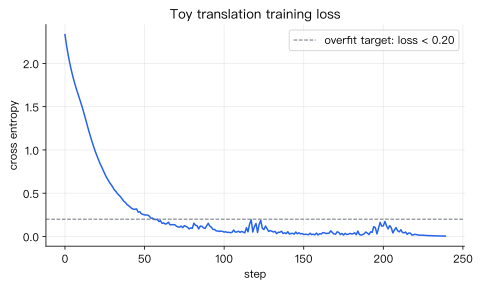

In [24]:
model = TinyTransformerSeq2Seq(
    src_vocab_size=len(src_tokens),
    tgt_vocab_size=len(tgt_tokens),
    d_model=48,
    num_heads=4,
    d_ff=128,
    num_layers=1,
    dropout=0.0,
    max_len=16,
    pad_id=PAD,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-3, weight_decay=0.0)
losses = []
t0 = time.time()

src_mask = make_padding_mask(src_batch)
tgt_mask = make_padding_mask(tgt_in_batch) & make_causal_mask(tgt_in_batch.size(1), device=device)

for step in range(240):
    model.train()
    optimizer.zero_grad()
    logits = model(src_batch, tgt_in_batch, src_mask, tgt_mask)
    loss = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        tgt_out_batch.reshape(-1),
        ignore_index=PAD,
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    losses.append(float(loss.detach().cpu()))

print(f"训练耗时: {time.time() - t0:.1f}s")
print(f"loss: {losses[0]:.4f} -> {losses[-1]:.4f}")
assert losses[-1] < 0.20, "toy translation should clearly overfit this tiny training set"

plt.figure(figsize=(7.5, 4))
plt.plot(losses, color=COLORS["blue"])
plt.axhline(0.20, color=COLORS["gray"], linestyle="--", linewidth=1, label="overfit target: loss < 0.20")
plt.title("Toy translation training loss")
plt.xlabel("step")
plt.ylabel("cross entropy")
plt.legend()
plt.show()

In [25]:
def decode_tgt(ids):
    words = []
    for i in ids:
        tok = tgt_itos[int(i)]
        if tok == "<eos>":
            break
        if tok not in ("<bos>", "<pad>"):
            words.append(tok)
    return words

@torch.no_grad()
def greedy_translate(model, src_words, max_len=8):
    model.eval()
    src = torch.tensor([[src_stoi[w] for w in src_words]], dtype=torch.long, device=device)
    src_mask = make_padding_mask(src)
    memory = model.encode(src, src_mask)
    ys = torch.tensor([[BOS]], dtype=torch.long, device=device)
    for _ in range(max_len):
        tgt_mask = make_causal_mask(ys.size(1), device=device)
        dec = model.decode(ys, memory, tgt_mask, src_mask)
        next_id = model.generator(dec[:, -1]).argmax(dim=-1, keepdim=True)
        ys = torch.cat([ys, next_id], dim=1)
        if int(next_id.item()) == EOS:
            break
    return ys[0].detach().cpu().tolist()

# 这里展示训练集内样本，因为本节目标是 overfit sanity check：
# 如果训练集样本都无法 greedy decode 正确，通常说明 mask/shift/模型结构还有 bug。
test_cases = [examples[i][0] for i in [0, 1, 2]]
exact_matches = 0
for s in test_cases:
    pred_ids = greedy_translate(model, s)
    expected = [color_map[w] for w in s[::-1]]
    pred_words = decode_tgt(pred_ids)
    exact_matches += int(pred_words == expected)
    print("src     :", s)
    print("expected:", expected)
    print("pred    :", pred_words)
    print("-" * 42)
print(f"train-sample exact-match accuracy: {exact_matches}/{len(test_cases)}")
print("说明：这是训练集内 greedy decode 体检，不是泛化评估。真实项目还需要 train/validation split。")
assert exact_matches == len(test_cases)

src     : ['yellow', 'yellow', 'blue', 'blue']
expected: ['B', 'B', 'Y', 'Y']
pred    : ['B', 'B', 'Y', 'Y']
------------------------------------------
src     : ['red', 'red']
expected: ['R', 'R']
pred    : ['R', 'R']
------------------------------------------
src     : ['black', 'yellow']
expected: ['Y', 'K']
pred    : ['Y', 'K']
------------------------------------------
train-sample exact-match accuracy: 3/3
说明：这是训练集内 greedy decode 体检，不是泛化评估。真实项目还需要 train/validation split。


**Overfit ≠ Generalization：一个 hold-out 反例**

上面训练集内 3/3 全对，只能证明模型"记住了"，不能证明它"学会了规则"。我们特意造几个 **训练时长度分布外**（训练用长度 2–4，测试用长度 5）的样本看看：

In [26]:
holdout_cases = [
    ["red", "blue", "green", "yellow", "black"],
    ["white", "white", "red", "blue", "green"],
    ["black", "yellow", "green", "red", "blue"],
]

holdout_matches = 0
for s in holdout_cases:
    pred_ids = greedy_translate(model, s)
    expected = [color_map[w] for w in s[::-1]]
    pred_words = decode_tgt(pred_ids)
    holdout_matches += int(pred_words == expected)
    print("src     :", s)
    print("expected:", expected)
    print("pred    :", pred_words)
    print("-" * 42)

print(f"hold-out exact-match accuracy: {holdout_matches}/{len(holdout_cases)}")
print()
print("观察：toy 模型没见过长度 5，输出通常残缺或错位。")
print("这不是模型 bug，而是它没学会 '反转任意长度' 这个抽象规则，")
print("只是记住了训练集里出现过的模式。")
print("真实项目里，train/validation split 就是用来揭穿这种伪装的。")

src     : ['red', 'blue', 'green', 'yellow', 'black']
expected: ['K', 'Y', 'G', 'B', 'R']
pred    : ['G', 'Y', 'K']
------------------------------------------
src     : ['white', 'white', 'red', 'blue', 'green']
expected: ['G', 'B', 'R', 'W', 'W']
pred    : ['G', 'B', 'W']
------------------------------------------
src     : ['black', 'yellow', 'green', 'red', 'blue']
expected: ['B', 'R', 'G', 'Y', 'K']
pred    : ['G', 'B', 'K']
------------------------------------------
hold-out exact-match accuracy: 0/3

观察：toy 模型没见过长度 5，输出通常残缺或错位。
这不是模型 bug，而是它没学会 '反转任意长度' 这个抽象规则，
只是记住了训练集里出现过的模式。
真实项目里，train/validation split 就是用来揭穿这种伪装的。


In [27]:
@torch.no_grad()
def teacher_forced_token_accuracy(model, src_batch, tgt_in_batch, tgt_out_batch):
    model.eval()
    src_mask = make_padding_mask(src_batch)
    tgt_mask = make_padding_mask(tgt_in_batch) & make_causal_mask(tgt_in_batch.size(1), device=device)
    logits = model(src_batch, tgt_in_batch, src_mask, tgt_mask)
    pred = logits.argmax(dim=-1)
    valid = tgt_out_batch != PAD
    token_acc = (pred[valid] == tgt_out_batch[valid]).float().mean().item()
    return token_acc

train_token_acc = teacher_forced_token_accuracy(model, src_batch, tgt_in_batch, tgt_out_batch)
print(f"teacher-forced train token accuracy: {train_token_acc:.2%}")
print("说明：这里是 toy 训练集上的 token accuracy，不代表真实翻译质量；它只用于确认模型确实学到了这个小任务。")
assert train_token_acc > 0.95

teacher-forced train token accuracy: 100.00%
说明：这里是 toy 训练集上的 token accuracy，不代表真实翻译质量；它只用于确认模型确实学到了这个小任务。


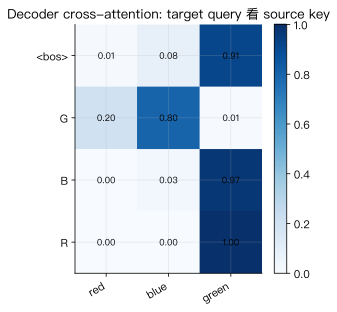

如果模型学会反转，生成 G/B/R 时常会分别关注 green/blue/red 附近。toy 模型很小，模式不一定完美，但矩阵已经能暴露它在看哪里。


In [28]:
@torch.no_grad()
def first_layer_cross_attention(model, src_words, tgt_words):
    model.eval()
    src = torch.tensor([[src_stoi[w] for w in src_words]], dtype=torch.long, device=device)
    tgt_in = torch.tensor([[BOS] + [tgt_stoi[w] for w in tgt_words]], dtype=torch.long, device=device)
    src_mask = make_padding_mask(src)
    tgt_mask = make_padding_mask(tgt_in) & make_causal_mask(tgt_in.size(1), device=device)
    memory = model.encode(src, src_mask)
    x = model.tgt_embed(tgt_in) * math.sqrt(model.d_model)
    x = model.pos(x)
    layer = model.decoder_layers[0]
    y = layer.norm1(x)
    self_out = layer.self_attn(y, y, y, mask=tgt_mask)
    x = x + layer.dropout(self_out)
    y = layer.norm2(x)
    _, cross_attn = layer.cross_attn(y, memory, memory, mask=src_mask, need_weights=True)
    return cross_attn[0, 0].detach().cpu().numpy()  # first head: [target_len, source_len]

src_words = ["red", "blue", "green"]
tgt_words = [color_map[w] for w in src_words[::-1]]
cross = first_layer_cross_attention(model, src_words, tgt_words)
row_labels = ["<bos>"] + tgt_words
show_matrix(cross, row_labels=row_labels, col_labels=src_words,
            title="Decoder cross-attention: target query 看 source key",
            cmap="Blues", vmin=0, vmax=1)
plt.show()
print("如果模型学会反转，生成 G/B/R 时常会分别关注 green/blue/red 附近。toy 模型很小，模式不一定完美，但矩阵已经能暴露它在看哪里。")

## 10 · GPT 路线：Decoder-only + Causal Language Model

GPT 保留 Transformer decoder 的 causal self-attention，但去掉 encoder 和 cross-attention。

训练目标变成：

$$
P(x_1,\dots,x_T) = \prod_{t=1}^{T} P(x_t \mid x_{<t})
$$

符号含义：

- `x_t`：第 `t` 个 token。
- `x_<t`：它之前的所有 token。
- `P(x_t | x_<t)`：给定历史前缀，预测下一个 token 的概率。

实际含义：训练时每个位置都在做“根据左边上下文预测当前 token”。这就是 next-token prediction。causal mask 保证模型不会偷看答案。

### 10.1 训练样本如何右移：公式和代码对齐

公式写的是 `P(x_t | x_<t)`，代码里通常写成“输入去掉最后一个 token，标签去掉第一个 token”：

```text
完整句子 : <bos>  i     like  red   today  .    <eos>
模型输入 : <bos>  i     like  red   today  .
预测标签 : i      like  red   today .      <eos>
```

含义是：输入位置 `t` 的 hidden state 只看见 `≤t` 的前缀，然后预测标签位置 `t+1` 的 token。两种说法本质一致，只是下标视角不同。

In [29]:
demo_lm = ["<bos>", "i", "like", "red", "today", ".", "<eos>"]
print(f"{'position':>8} | {'model input':>12} | {'label to predict':>16}")
print("-" * 44)
for i in range(len(demo_lm) - 1):
    print(f"{i:>8} | {demo_lm[i]:>12} | {demo_lm[i + 1]:>16}")

position |  model input | label to predict
--------------------------------------------
       0 |        <bos> |                i
       1 |            i |             like
       2 |         like |              red
       3 |          red |            today
       4 |        today |                .
       5 |            . |            <eos>


GPT toy 训练耗时: 0.2s
loss: 2.5451 -> 0.3161
next-token train token accuracy (全部位置)      : 80.56%
next-token train token accuracy (仅可预测位置)  : 100.00%
说明：前两个位置是天然歧义（主语 3 选 1、动词 2 选 1），不参与 overfit 断言。


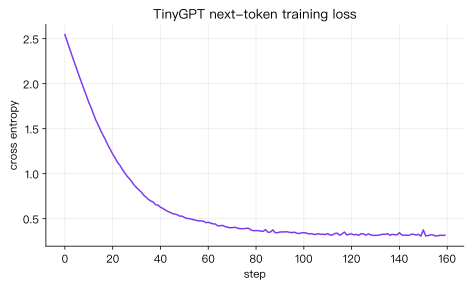

In [30]:
class DecoderOnlyLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        y = self.norm1(x)
        x = x + self.dropout(self.self_attn(y, y, y, mask=mask))
        y = self.norm2(x)
        x = x + self.ffn(y)
        return x


class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=4, d_ff=96, num_layers=1,
                 dropout=0.1, max_len=64, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        self.layers = nn.ModuleList([
            DecoderOnlyLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None):
        h = self.embed(x) * math.sqrt(self.d_model)
        h = self.pos(h)
        for layer in self.layers:
            h = layer(h, mask)
        return self.lm_head(self.norm(h))


lm_tokens = ["<pad>", "<bos>", "<eos>", "i", "you", "we", "like", "prefer", "red", "blue", "green", "today", "."]
lm_stoi = {tok: i for i, tok in enumerate(lm_tokens)}
lm_itos = {i: tok for tok, i in lm_stoi.items()}

# 用确定性规则生成语料：(subj, verb) 唯一决定 color。
# 这样从 <bos> 开始，除了主语选择的两次自然歧义外，其余 token 都是可完全预测的，
# 保证 GPT toy 能真正 overfit 到高精度。
lm_color_rule = {
    ("i", "like"):    "red",
    ("i", "prefer"):  "blue",
    ("you", "like"):  "green",
    ("you", "prefer"):"red",
    ("we", "like"):   "blue",
    ("we", "prefer"): "green",
}
lm_sentences = []
for (subj, verb), color in lm_color_rule.items():
    for _ in range(3):
        lm_sentences.append(["<bos>", subj, verb, color, "today", ".", "<eos>"])

lm_ids = [[lm_stoi[t] for t in sent] for sent in lm_sentences]
lm_batch = pad_sequences(lm_ids, pad_id=lm_stoi["<pad>"]).to(device)
lm_x = lm_batch[:, :-1]
lm_y = lm_batch[:, 1:]

gpt = TinyGPT(
    len(lm_tokens),
    d_model=24,
    num_heads=3,
    d_ff=64,
    dropout=0.05,
    pad_id=lm_stoi["<pad>"],
).to(device)
gpt_opt = torch.optim.AdamW(gpt.parameters(), lr=3e-3)
gpt_losses = []
gpt_mask = make_padding_mask(lm_x, pad_id=lm_stoi["<pad>"]) & make_causal_mask(lm_x.size(1), device=device)

t0 = time.time()
for step in range(160):
    gpt.train()
    gpt_opt.zero_grad()
    logits = gpt(lm_x, gpt_mask)
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), lm_y.reshape(-1),
                           ignore_index=lm_stoi["<pad>"])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gpt.parameters(), 1.0)
    gpt_opt.step()
    gpt_losses.append(float(loss.detach().cpu()))

print(f"GPT toy 训练耗时: {time.time() - t0:.1f}s")
print(f"loss: {gpt_losses[0]:.4f} -> {gpt_losses[-1]:.4f}")
assert gpt_losses[-1] < gpt_losses[0]

with torch.no_grad():
    gpt.eval()
    pred = gpt(lm_x, gpt_mask).argmax(dim=-1)
    valid = lm_y != lm_stoi["<pad>"]
    gpt_token_acc = (pred[valid] == lm_y[valid]).float().mean().item()

    # 位置解释：
    # 输入 x = <bos> subj verb color today .   (label 是每个位置的"下一个 token")
    # label 位置    0    1    2     3    4  5
    # label 位置 0 (预测主语) 天然是 3 选 1，位置 1 (预测动词) 天然是 2 选 1，
    # 这两处即使完美 overfit 也不会 100%；后 4 个位置有确定规则，可完全预测。
    # 所以真正衡量"是否学到规则"的是**可预测位置的 accuracy**。
    predictable_mask = valid.clone()
    predictable_mask[:, :2] = False
    gpt_rule_acc = (pred[predictable_mask] == lm_y[predictable_mask]).float().mean().item()

print(f"next-token train token accuracy (全部位置)      : {gpt_token_acc:.2%}")
print(f"next-token train token accuracy (仅可预测位置)  : {gpt_rule_acc:.2%}")
print("说明：前两个位置是天然歧义（主语 3 选 1、动词 2 选 1），不参与 overfit 断言。")
assert gpt_rule_acc > 0.90

plt.figure(figsize=(7.5, 4))
plt.plot(gpt_losses, color=COLORS["purple"])
plt.title("TinyGPT next-token training loss")
plt.xlabel("step")
plt.ylabel("cross entropy")
plt.show()

In [31]:
def top_k_sample(logits, temperature=1.0, top_k=5):
    logits = logits / max(temperature, 1e-6)
    if top_k is not None and top_k < logits.numel():
        vals, idx = torch.topk(logits, k=top_k)
        probs = torch.softmax(vals, dim=-1)
        choice = torch.multinomial(probs, num_samples=1)
        return idx[choice].item()
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()

@torch.no_grad()
def generate_gpt(prompt, max_new_tokens=8, temperature=0.8, top_k=5):
    gpt.eval()
    ids = [lm_stoi[t] for t in prompt]
    for _ in range(max_new_tokens):
        x = torch.tensor([ids], dtype=torch.long, device=device)
        mask = make_causal_mask(x.size(1), device=device)
        logits = gpt(x, mask)[0, -1].detach().cpu()
        next_id = top_k_sample(logits, temperature=temperature, top_k=top_k)
        ids.append(next_id)
        if lm_itos[next_id] == "<eos>":
            break
    return [lm_itos[i] for i in ids]

for prompt in [["<bos>", "i"], ["<bos>", "we", "prefer"], ["<bos>", "you", "like"]]:
    print("prompt:", prompt)
    print("sample:", generate_gpt(prompt, temperature=0.7, top_k=4))
    print("-" * 42)

if HAS_WIDGETS:
    def interactive_generate(temperature=0.8, top_k=4):
        torch.manual_seed(SEED)
        print(generate_gpt(["<bos>", "i"], temperature=temperature, top_k=top_k))
    interact(
        interactive_generate,
        temperature=FloatSlider(value=0.8, min=0.2, max=2.0, step=0.1, description="temperature"),
        top_k=IntSlider(value=4, min=1, max=8, step=1, description="top_k"),
    )

prompt: ['<bos>', 'i']
sample: ['<bos>', 'i', 'prefer', 'blue', 'today', '.', '<eos>']
------------------------------------------
prompt: ['<bos>', 'we', 'prefer']
sample: ['<bos>', 'we', 'prefer', 'green', 'today', '.', '<eos>']
------------------------------------------
prompt: ['<bos>', 'you', 'like']
sample: ['<bos>', 'you', 'like', 'green', 'today', '.', '<eos>']
------------------------------------------


interactive(children=(FloatSlider(value=0.8, description='temperature', max=2.0, min=0.2), IntSlider(value=4, …

### 10.2 GPT 采样参数的实际含义

- `temperature`：控制 logits 的平滑程度。小于 1 更保守，大于 1 更随机。
- `top_k`：只从概率最高的 `k` 个 token 中采样，减少低概率噪声。
- greedy decoding：每步都选最大概率 token，稳定但容易重复。

这些参数不改变模型本身，只改变“如何从模型给出的概率分布里选 token”。

## 11 · BERT 路线：Encoder-only + Masked Language Modeling

BERT 保留 Transformer encoder 的双向 self-attention。它不做自左向右生成，而是把句子中的一部分 token 替换为 `[MASK]`，要求模型利用左右上下文预测原 token。

训练目标可以写成：

$$
L_{MLM} = - \sum_{i \in M} \log P(x_i \mid x_{\setminus M})
$$

符号含义：

- `M`：被 mask 的位置集合。
- `x_i`：原始 token。
- `x_{\setminus M}`：把 mask 位置遮住后的可见输入。
- `P(x_i | x_{\setminus M})`：利用双向上下文预测原 token 的概率。

实际含义：BERT 学到的是“带上下文的 token 表示”。同一个词在不同句子里可以有不同向量。

### 11.1 这是 BERT 的最小玩具版，不是完整预训练复刻

为了让 notebook 能在十几秒内跑完，下面只保留 BERT 最核心的 MLM 思想：**把一个 token 替换成 `[MASK]`，用双向上下文预测它。**

真实 BERT 预训练还有更多细节：

| 设计 | 原始 BERT | 本教程 toy 版 |
|---|---|---|
| mask 比例 | 随机选 15% token | 固定 mask 颜色位置 |
| 80/10/10 规则 | 80% `[MASK]`，10% 随机词，10% 保持原词 | 全部替换成 `[MASK]` |
| token type embedding | 区分句子 A/B | 省略 |
| NSP | 原论文有 Next Sentence Prediction | 省略 |
| 目标 | 大规模通用预训练 | 说明 encoder-only + 双向上下文 |

这样做的目的不是复刻 BERT 训练，而是让你看懂“为什么 encoder-only 适合理解任务”。

BERT MLM toy 训练耗时: 0.3s
MLM loss: 2.7119 -> 0.0150
masked-token train accuracy: 100.00%


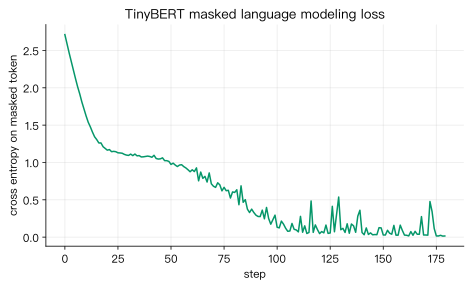

In [32]:
BERT_PAD = 0
BERT_MASK = 1
BERT_CLS = 2
BERT_SEP = 3
bert_tokens = ["<pad>", "[MASK]", "[CLS]", "[SEP]", "i", "you", "we", "like", "prefer", "red", "blue", "green", "today", "."]
bert_stoi = {tok: i for i, tok in enumerate(bert_tokens)}
bert_itos = {i: tok for tok, i in bert_stoi.items()}

class TinyBERTForMLM(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=4, d_ff=96, num_layers=1,
                 dropout=0.1, max_len=64, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.mlm_head = nn.Linear(d_model, vocab_size)

    def encode(self, x, mask):
        h = self.embed(x) * math.sqrt(self.d_model)
        h = self.pos(h)
        for layer in self.layers:
            h = layer(h, mask)
        return self.norm(h)

    def forward(self, x, mask):
        return self.mlm_head(self.encode(x, mask))


# 让 masked token 有可学习规律：颜色由 (subject, verb) 决定。
# 如果上下文和被 mask 的词完全独立，MLM 最多只能学到边际分布，那不是一个好教学 demo。
bert_color_rule = {
    ("i", "like"): "red",
    ("i", "prefer"): "blue",
    ("you", "like"): "green",
    ("you", "prefer"): "red",
    ("we", "like"): "blue",
    ("we", "prefer"): "green",
}
bert_sentences = []
for (subj, verb), color in bert_color_rule.items():
    for _ in range(3):
        bert_sentences.append(["[CLS]", subj, verb, color, "today", ".", "[SEP]"])

bert_inputs, bert_labels, cls_labels = [], [], []
for sent in bert_sentences:
    ids = [bert_stoi[t] for t in sent]
    color_pos = 3
    labels = [-100] * len(ids)
    labels[color_pos] = ids[color_pos]
    ids[color_pos] = BERT_MASK
    bert_inputs.append(ids)
    bert_labels.append(labels)
    cls_labels.append(0 if sent[1] in ("i", "we") else 1)  # toy 分类：第一人称/非第一人称

bert_x = pad_sequences(bert_inputs, pad_id=BERT_PAD).to(device)
bert_y = pad_sequences(bert_labels, pad_id=-100).to(device)
bert_cls_y = torch.tensor(cls_labels, dtype=torch.long, device=device)
bert_mask = make_padding_mask(bert_x, pad_id=BERT_PAD)

bert = TinyBERTForMLM(
    len(bert_tokens),
    d_model=24,
    num_heads=3,
    d_ff=64,
    dropout=0.05,
    pad_id=BERT_PAD,
).to(device)
bert_opt = torch.optim.AdamW(bert.parameters(), lr=3e-3)
mlm_losses = []

t0 = time.time()
for step in range(180):
    bert.train()
    bert_opt.zero_grad()
    logits = bert(bert_x, bert_mask)
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), bert_y.reshape(-1), ignore_index=-100)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(bert.parameters(), 1.0)
    bert_opt.step()
    mlm_losses.append(float(loss.detach().cpu()))

print(f"BERT MLM toy 训练耗时: {time.time() - t0:.1f}s")
print(f"MLM loss: {mlm_losses[0]:.4f} -> {mlm_losses[-1]:.4f}")
assert mlm_losses[-1] < mlm_losses[0]

with torch.no_grad():
    bert.eval()
    pred = bert(bert_x, bert_mask).argmax(dim=-1)
    valid = bert_y != -100
    mlm_acc = (pred[valid] == bert_y[valid]).float().mean().item()
print(f"masked-token train accuracy: {mlm_acc:.2%}")
assert mlm_acc > 0.85

plt.figure(figsize=(7.5, 4))
plt.plot(mlm_losses, color=COLORS["green"])
plt.title("TinyBERT masked language modeling loss")
plt.xlabel("step")
plt.ylabel("cross entropy on masked token")
plt.show()

In [33]:
@torch.no_grad()
def predict_mask(sentence):
    bert.eval()
    ids = [bert_stoi[t] for t in sentence]
    x = torch.tensor([ids], dtype=torch.long, device=device)
    mask = make_padding_mask(x, pad_id=BERT_PAD)
    logits = bert(x, mask)[0]
    mask_pos = sentence.index("[MASK]")
    probs = torch.softmax(logits[mask_pos], dim=-1).detach().cpu()
    top = torch.topk(probs, k=5)
    return [(bert_itos[int(i)], float(p)) for p, i in zip(top.values, top.indices)]

for sent in [
    ["[CLS]", "i", "like", "[MASK]", "today", ".", "[SEP]"],
    ["[CLS]", "you", "prefer", "[MASK]", "today", ".", "[SEP]"],
]:
    print("input:", sent)
    print("top predictions:", predict_mask(sent))
    print("-" * 50)

# CLS 分类头：真实 BERT 微调常取 [CLS] 位置向量接一个线性分类器。
cls_head = nn.Linear(bert.d_model, 2).to(device)
cls_opt = torch.optim.AdamW(list(bert.parameters()) + list(cls_head.parameters()), lr=2e-3)
cls_losses = []
for step in range(45):
    bert.train()
    cls_head.train()
    cls_opt.zero_grad()
    hidden = bert.encode(bert_x, bert_mask)
    cls_vec = hidden[:, 0, :]  # [CLS] 位置
    cls_logits = cls_head(cls_vec)
    loss = F.cross_entropy(cls_logits, bert_cls_y)
    loss.backward()
    cls_opt.step()
    cls_losses.append(float(loss.detach().cpu()))

with torch.no_grad():
    pred = cls_head(bert.encode(bert_x, bert_mask)[:, 0, :]).argmax(dim=-1)
    acc = (pred == bert_cls_y).float().mean().item()
print(f"[CLS] toy classification loss: {cls_losses[0]:.4f} -> {cls_losses[-1]:.4f}; acc={acc:.2f}")
assert cls_losses[-1] < cls_losses[0]

input: ['[CLS]', 'i', 'like', '[MASK]', 'today', '.', '[SEP]']
top predictions: [('red', 0.9940126538276672), ('green', 0.0035456386394798756), ('blue', 0.0016663279384374619), ('prefer', 0.0001736095146043226), ('<pad>', 0.00015336218348238617)]
--------------------------------------------------
input: ['[CLS]', 'you', 'prefer', '[MASK]', 'today', '.', '[SEP]']
top predictions: [('red', 0.9737410545349121), ('green', 0.02482282929122448), ('blue', 0.0006238218047656119), ('<pad>', 0.00021627236856147647), ('prefer', 0.00015799046377651393)]
--------------------------------------------------
[CLS] toy classification loss: 0.7774 -> 0.0072; acc=1.00


## 12 · 工程实践：shape、teacher forcing、KV cache 和常见 bug

Transformer 工程里最常见的问题不是公式，而是 shape 和 mask。

### 12.1 Shape 速查

| 名称 | 常见 shape | 说明 |
|---|---|---|
| token ids | `[B, T]` | 一个 batch 的整数 token |
| embedding | `[B, T, D]` | token id 查表后的向量 |
| attention scores | `[B, H, T_q, T_k]` | 每个 head 的注意力打分 |
| padding mask | `[B, 1, 1, T_k]` | 对 key 维遮 pad |
| causal mask | `[1, 1, T, T]` | 对未来位置遮挡 |
| logits | `[B, T, V]` | 每个位置对词表的预测 |

### 12.2 Teacher forcing

训练 seq2seq 时，decoder 输入是正确 target 右移一位：

```text
target     : R B G <eos>
decoder in : <bos> R B G
label      : R B G <eos>
```

这让每个位置都能并行计算 loss；推理时才改成一步步把模型自己的输出喂回去。

### 12.3 Mask 工程 checklist

写 Transformer 代码时，每次接入一个新框架或新 API，都先问这 5 个问题：

| 问题 | 为什么重要 |
|---|---|
| mask 的 shape 是什么？ | `[B,1,1,T]`、`[B,T]`、`[T,T]` 都可能出现 |
| `True` 表示可见还是遮住？ | 本教程是 `True=可见`，但部分 PyTorch API 相反 |
| mask 是 bool 还是 additive？ | additive mask 常用 `0/-inf` 加到 scores 上 |
| padding mask 遮的是 key 还是 query？ | 多数实现主要遮 key，query 侧 pad 靠 loss ignore |
| 是否存在全遮行？ | 全遮行做 softmax 会得到 NaN |

调试时最可靠的方法：打印一个 batch 的 mask 矩阵，并确认 `<pad>` 列、未来列是否真的是不可见。

In [34]:
def inspect_shapes():
    B, S, T, D, H, V = 2, 5, 4, 32, 4, 11
    src = torch.tensor([[3, 4, 5, 0, 0], [6, 7, 8, 9, 0]])
    tgt_in = torch.tensor([[1, 4, 5, 0], [1, 6, 7, 8]])
    emb = torch.randn(B, T, D)
    scores = torch.randn(B, H, T, S)
    src_mask = make_padding_mask(src)
    tgt_mask = make_padding_mask(tgt_in) & make_causal_mask(T)
    logits = torch.randn(B, T, V)
    shapes = {
        "src": tuple(src.shape),
        "tgt_in": tuple(tgt_in.shape),
        "embedding": tuple(emb.shape),
        "attention_scores": tuple(scores.shape),
        "src_mask": tuple(src_mask.shape),
        "tgt_mask": tuple(tgt_mask.shape),
        "logits": tuple(logits.shape),
    }
    for k, v in shapes.items():
        print(f"{k:>18}: {v}")
    assert src_mask.shape == (B, 1, 1, S)
    assert tgt_mask.shape == (B, 1, T, T)
    assert logits.shape == (B, T, V)

inspect_shapes()

               src: (2, 5)
            tgt_in: (2, 4)
         embedding: (2, 4, 32)
  attention_scores: (2, 4, 4, 5)
          src_mask: (2, 1, 1, 5)
          tgt_mask: (2, 1, 4, 4)
            logits: (2, 4, 11)


### 12.4 KV cache 的直觉

GPT 推理时，如果每生成一个新 token 都把整个前缀重新算一遍，会重复计算历史 token 的 `K` 和 `V`。KV cache 做的事情很朴素：

1. 第一步算出历史 token 的 key/value 后缓存起来。
2. 下一步只为新 token 算 query/key/value。
3. 新 query 去 attend “缓存的旧 K/V + 新 K/V”。

复杂度直觉：

- 无 cache：每一步重算整个前缀，生成 `T` 个 token 的 attention 代价近似 `1^2 + 2^2 + ... + T^2 = O(T^3)`。
- 有 cache：每一步只让新 query 看历史 key，代价近似 `1 + 2 + ... + T = O(T^2)`。

> 严格地说，第 `t` 步 attention 是 `O(t · d)` 而非纯 `t^2`（每个 key 还要点积 d 维）。这里为教学直观省略了 `d` 因子和常数，量级正确即可。

训练通常不用 KV cache，因为 teacher forcing 允许一次性并行算完整序列；推理才最需要 cache。

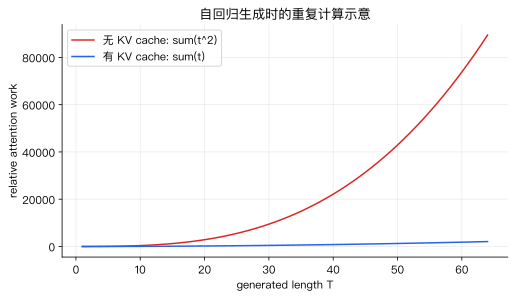

T= 8: no_cache=   204, with_cache=   36
T=16: no_cache=  1496, with_cache=  136
T=32: no_cache= 11440, with_cache=  528
T=64: no_cache= 89440, with_cache= 2080


In [35]:
lengths = np.arange(1, 65)
no_cache = np.cumsum(lengths ** 2)
with_cache = np.cumsum(lengths)

plt.figure(figsize=(8, 4.2))
plt.plot(lengths, no_cache, label="无 KV cache: sum(t^2)", color=COLORS["red"])
plt.plot(lengths, with_cache, label="有 KV cache: sum(t)", color=COLORS["blue"])
plt.title("自回归生成时的重复计算示意")
plt.xlabel("generated length T")
plt.ylabel("relative attention work")
plt.legend()
plt.show()

for T in [8, 16, 32, 64]:
    print(f"T={T:>2}: no_cache={sum(i*i for i in range(1, T+1)):>6}, with_cache={sum(range(1, T+1)):>5}")

#### 12.4.1 KV cache 的最小实现

上面只讲了复杂度直觉。真正的实现其实很短——**核心只有一件事：把每一步算过的 K 和 V 拼到一个 tensor 上，下一步用**。

In [36]:
class CachedAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

    def _split(self, x):
        B, T, D = x.shape
        return x.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

    def forward(self, x, past_kv=None, causal=True):
        # x: [B, T_new, D]   past_kv: (K_cache, V_cache) 或 None
        q = self._split(self.q_proj(x))          # [B, H, T_new, Dh]
        k = self._split(self.k_proj(x))          # [B, H, T_new, Dh]
        v = self._split(self.v_proj(x))          # [B, H, T_new, Dh]

        past_len = 0
        if past_kv is not None:
            k_past, v_past = past_kv
            past_len = k_past.shape[2]
            k = torch.cat([k_past, k], dim=2)    # 在时间维拼接
            v = torch.cat([v_past, v], dim=2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if causal:
            # 每个新 query 位置 i 只能看见 key 位置 <= past_len + i
            T_new = q.shape[2]
            T_total = k.shape[2]
            q_pos = torch.arange(past_len, past_len + T_new).view(-1, 1)
            k_pos = torch.arange(T_total).view(1, -1)
            mask = (k_pos <= q_pos)              # [T_new, T_total]
            scores = scores.masked_fill(~mask, -1e9)

        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, v).transpose(1, 2).contiguous()
        B, T_new = out.shape[0], out.shape[1]
        out = out.view(B, T_new, -1)
        return self.out_proj(out), (k, v)        # 把新的 K/V 返回给下一步用


torch.manual_seed(0)
d_model, num_heads = 16, 4
attn = CachedAttention(d_model, num_heads).eval()
seq_len = 5

# 方式 A: 一次算完整个序列 (训练/prefill 阶段, 带 causal mask)
x_full = torch.randn(1, seq_len, d_model)
with torch.no_grad():
    out_full, _ = attn(x_full, past_kv=None, causal=True)

# 方式 B: 逐 token 生成, 每步只喂 1 个 token 但拼上 KV cache
past_kv = None
out_step = []
with torch.no_grad():
    for t in range(seq_len):
        y, past_kv = attn(x_full[:, t:t+1, :], past_kv=past_kv, causal=True)
        out_step.append(y)
out_step = torch.cat(out_step, dim=1)

diff = (out_full - out_step).abs().max().item()
print(f"一次性 prefill vs 逐步 + KV cache, 最大数值差: {diff:.2e}")
print(f"past_kv 最终 shape: K={tuple(past_kv[0].shape)}  V={tuple(past_kv[1].shape)}")
print("两种方式在数值上严格一致——这就是 KV cache 能在生成时替代重复计算的原因。")

assert diff < 1e-5, "带 cache 的逐步计算应和一次性计算结果一致"

一次性 prefill vs 逐步 + KV cache, 最大数值差: 7.45e-08
past_kv 最终 shape: K=(1, 4, 5, 4)  V=(1, 4, 5, 4)
两种方式在数值上严格一致——这就是 KV cache 能在生成时替代重复计算的原因。


**关键观察**：

- **训练/prefill**：一次性喂完整序列，`past_kv=None`。
- **推理生成**：每步只喂新的 1 个 token，但把之前的 K/V 从 cache 里拼上去。
- 两种方式的输出**在数值上完全一致**——上面的 `assert diff < 1e-5` 就是这个保证。

**为什么能 cache**：因为 attention 里 K 和 V 只依赖各自位置的输入，**不依赖 query**。历史位置的 K/V 一旦算出来就不会变，可以复用。

**显存权衡**：cache 总大小 ≈ `2 · B · L · T · H_kv · d_head · dtype`（B 是并发请求数，L 是层数，H_kv 是 KV head 数，可能小于 Q head 数）。这就是前面 GQA 想压缩的东西——**减少 H_kv 就能线性减少 KV cache**。13.3 节会用这个公式代入真实模型算显存。

### 12.5 常见 bug 清单

| 现象 | 高概率原因 | 快速检查 |
|---|---|---|
| loss 不下降 | mask 方向反了，或 label 没右移 | 打印第一条样本的 `tgt_in` 和 `label` |
| attention 全看 `<pad>` | padding mask 布尔含义反了 | 确认 `True=可见`，`False=遮住` |
| shape broadcast 报错 | mask 少了 head/query 维 | padding mask 应是 `[B,1,1,T]` |
| 生成时偷看未来 | 忘了 causal mask | attention 矩阵应为下三角 |
| 训练很慢 | toy 模型用了过大的 `D/H/layers` | 先用 `D=32,H=4,layers=1` 跑通 |
| 输出重复 | greedy 太保守或模型太小 | 试 temperature/top-k，并检查训练语料多样性 |

## 13 · LLM 推理工程：从模型到线上服务

前面章节讲的是"如何把一个 Transformer 训练出来"。工程里另一半问题是：**把训练好的模型跑起来**。当 Transformer 变成大语言模型上线服务时，工程侧的问题会变得非常具体：

- 显存够不够？
- 首 token 为什么慢？
- 长上下文为什么贵？
- temperature / top-k / top-p 具体在做什么？
- 一条请求走完到底经过了哪些阶段？

这一章把这些问题串起来。

### 13.1 一条 LLM 请求的完整链路

用户感知到的"慢"不是一个单点问题。提交 prompt 后，请求会经过五个阶段，每一步都可能是瓶颈：

| 阶段 | 做什么 | 主要瓶颈 | 优化方向 |
|---|---|---|---|
| **Tokenize** | 把文本转成 token id | 长 prompt、复杂模板、多轮历史拼接 | 缓存系统 prompt、控制历史长度 |
| **Prefill** | 并行处理完整 prompt，生成第一步所需 KV cache | 上下文越长，计算和显存压力越大 | prompt 压缩、chunk prefill、批处理、FlashAttention |
| **Decode** | 每步生成一个 token，并追加 KV cache | 逐步依赖强，GPU 容易吃不满 | continuous batching、PagedAttention、speculative decoding |
| **Sampling** | 根据 logits 选下一个 token | 参数不合适导致重复、跑题或格式不稳 | temperature、top-p、重复惩罚、结构化约束 |
| **Detokenize** | token id → 文本 | 一般不是瓶颈 | 流式返回 |

**首 token 延迟主要受 prefill 影响，后续输出速度主要受 decode 吞吐影响**。这是工程侧最重要的直觉，后面各节都会回到它。

### 13.2 Prefill vs Decode：为什么是两个阶段

看一次真实生成的时序：

```text
用户 prompt      : 一段 4000 tokens 的输入
模型要输出       : 300 tokens 的回答

阶段 A (Prefill) : 一次性处理 4000 个 token, 建立完整 KV cache
                   这一步只算 1 次, 但计算量 ≈ 4000² (attention 是 O(T²))
                   首 token 出来之前, 用户就在等这一步

阶段 B (Decode)  : 逐个生成 300 个 token, 每步只算 1 个 query 看历史 K/V
                   每步计算量 ≈ T (T 从 4001 增长到 4300)
                   用户看到的流式输出速度就是 decode 吞吐
```

**两阶段的计算特征完全不同**：

| 维度 | Prefill | Decode |
|---|---|---|
| 输入 | 一次几千个 token | 每步 1 个 token |
| GPU 利用率 | 高（大矩阵乘法） | 低（小矩阵乘法，容易 memory-bound） |
| 延迟决定 | 首 token 出现时间 | 后续 token 生成速度 |
| 优化重点 | 减少计算量（chunk、压缩、Flash） | 提升吞吐（batching、cache、speculative） |

**一个线上延迟例子**：

```text
总耗时 ≈ tokenize + prefill(4000) + decode(300 tokens) + 网络/渲染
```

如果首 token 慢，优先看 prompt 长度、排队和 prefill；如果流式慢，优先看 decode 吞吐、batching 和 KV cache。

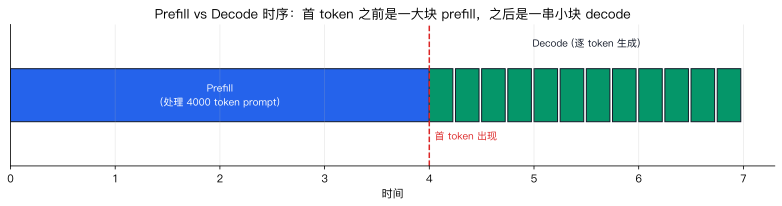

直觉：prefill 时间和 prompt 长度成 O(T²) 增长, decode 每步时间基本恒定。
所以 '首 token 慢' 和 '流式慢' 是两种不同的性能问题, 优化方向也不同。


In [37]:
# 一次请求的时序示意：prefill 是一个大块, decode 是一串小块。
fig, ax = plt.subplots(figsize=(11, 3.0))

prefill_dur = 4.0   # 教学示意用时间, 不是真实秒数
decode_step = 0.25
n_decode = 12

# prefill 大块
ax.barh(0, prefill_dur, left=0, color=COLORS["blue"], edgecolor=COLORS["dark"], height=0.6)
ax.text(prefill_dur / 2, 0, f"Prefill\n(处理 4000 token prompt)", ha="center", va="center", color="white", fontsize=10)

# decode 一串小块
for i in range(n_decode):
    ax.barh(0, decode_step * 0.9, left=prefill_dur + i * decode_step, color=COLORS["green"], edgecolor=COLORS["dark"], height=0.6)
ax.text(prefill_dur + n_decode * decode_step / 2, 0.55, "Decode (逐 token 生成)", ha="center", color=COLORS["dark"], fontsize=10)

# 首 token 出现时刻
ax.axvline(prefill_dur, color=COLORS["red"], linestyle="--", lw=1.5)
ax.text(prefill_dur + 0.05, -0.5, "首 token 出现", color=COLORS["red"], fontsize=10)

ax.set_yticks([])
ax.set_xlim(0, prefill_dur + n_decode * decode_step + 0.3)
ax.set_ylim(-0.8, 0.8)
ax.set_xlabel("时间")
ax.set_title("Prefill vs Decode 时序：首 token 之前是一大块 prefill，之后是一串小块 decode")
plt.tight_layout()
plt.show()

print("直觉：prefill 时间和 prompt 长度成 O(T²) 增长, decode 每步时间基本恒定。")
print("所以 '首 token 慢' 和 '流式慢' 是两种不同的性能问题, 优化方向也不同。")

### 13.3 KV cache 的完整显存公式

前面 12.4.1 讲了 KV cache 的实现，这里补上真实显存的计算方式。**全部层加起来**的 KV cache 总大小：

$$
\text{KV cache total} = 2 \cdot B \cdot L \cdot T \cdot H_{kv} \cdot d_{head} \cdot \text{bytes}
$$

- `2`：K 和 V 各存一份。
- `B`：batch size，同时在服务的请求数。
- `L`：Transformer 层数（**这里把所有层求和**，所以要乘 L）。
- `T`：prompt + 已生成 token 总长度。
- `H_kv`：KV head 数（MHA 时 = H，GQA/MQA 时 < H）。
- `d_head`：每个 head 的维度。
- `bytes`：数据类型字节数（FP16/BF16 = 2 字节，INT8 quant = 1 字节）。

> 注意区分单层 vs 总量：5.1 节里给的是**单层**公式（少乘 `L`），这里给的是**全部层**总显存。工程配置常混用这两个口径，看到显存数字先确认哪一种。

**代入 LLaMA-3-70B 的数字**：`L=80, H_kv=8, d_head=128, FP16`。单请求 T=8192 时：

$$
2 \times 1 \times 80 \times 8192 \times 8 \times 128 \times 2 \text{ bytes} \approx 2.5 \text{ GB}
$$

一个 H100（80GB）除去模型权重（70B FP16 需 ~140GB，实际靠张量并行拆到多卡），剩下的显存必须被 batch 里所有请求的 KV cache 分。这就是**为什么长上下文贵、batch 开不大**。

这也直接解释了 GQA/MQA（5.1 节）为什么被现代 LLM 全面采用——它是唯一能**线性压缩 KV cache** 的结构改动。

In [38]:
def kv_cache_gb(batch, layers, seq_len, kv_heads, d_head, bytes_per_value=2):
    # 全部层加起来的 KV cache 总量
    total_bytes = 2 * batch * layers * seq_len * kv_heads * d_head * bytes_per_value
    return total_bytes / (1024 ** 3)

configs = [
    ("LLaMA-3-8B  GQA",  32,   8, 128, 2),   # 8B: 32 层, 32 Q heads / 8 KV heads (GQA)
    ("LLaMA-3-70B GQA",  80,   8, 128, 2),   # 70B: 80 层, 64 Q heads / 8 KV heads
    ("Qwen-2-72B  GQA",  80,   8, 128, 2),
]

print(f"{'model':>18}  {'seq_len':>7}  {'KV cache total (GB, B=1)':>26}")
for name, layers, kv_heads, d_head, b in configs:
    for T in [2048, 8192, 32768]:
        print(f"{name:>18}  {T:>7}  {kv_cache_gb(1, layers, T, kv_heads, d_head, b):>26.2f}")

print()
print("观察：同一个模型, 上下文从 2k -> 32k, KV cache 显存线性增长 16 倍。")
print("这是长上下文推理最主要的显存压力来源。")

             model  seq_len    KV cache total (GB, B=1)
   LLaMA-3-8B  GQA     2048                        0.25
   LLaMA-3-8B  GQA     8192                        1.00
   LLaMA-3-8B  GQA    32768                        4.00
   LLaMA-3-70B GQA     2048                        0.62
   LLaMA-3-70B GQA     8192                        2.50
   LLaMA-3-70B GQA    32768                       10.00
   Qwen-2-72B  GQA     2048                        0.62
   Qwen-2-72B  GQA     8192                        2.50
   Qwen-2-72B  GQA    32768                       10.00

观察：同一个模型, 上下文从 2k -> 32k, KV cache 显存线性增长 16 倍。
这是长上下文推理最主要的显存压力来源。


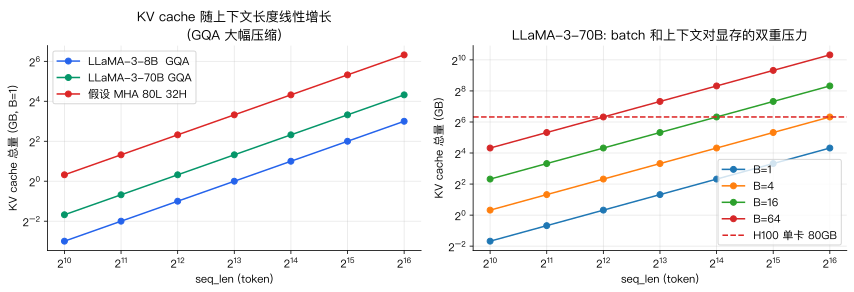

直觉：KV cache 沿 seq_len 和 batch 都是线性的, 长上下文 + 高并发是显存杀手。
这也是为什么 vLLM 的 PagedAttention 和 GQA/MQA 在长上下文 serving 上是刚需。


In [39]:
# KV cache 随上下文长度、batch size 的增长曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# 左图：不同模型 KV cache vs seq_len (B=1)
seq_lens = np.array([1024, 2048, 4096, 8192, 16384, 32768, 65536])
models = [
    ("LLaMA-3-8B  GQA",  32,  8, 128, 2, COLORS["blue"]),
    ("LLaMA-3-70B GQA",  80,  8, 128, 2, COLORS["green"]),
    ("假设 MHA 80L 32H",  80, 32, 128, 2, COLORS["red"]),
]
ax = axes[0]
for name, L, H_kv, dh, b, c in models:
    gb = [2 * 1 * L * T * H_kv * dh * b / (1024 ** 3) for T in seq_lens]
    ax.plot(seq_lens, gb, marker="o", label=name, color=c)
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("seq_len (token)")
ax.set_ylabel("KV cache 总量 (GB, B=1)")
ax.set_title("KV cache 随上下文长度线性增长\n(GQA 大幅压缩)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# 右图：LLaMA-3-70B 不同 batch, 不同 seq_len
ax = axes[1]
batches = [1, 4, 16, 64]
for B in batches:
    gb = [2 * B * 80 * T * 8 * 128 * 2 / (1024 ** 3) for T in seq_lens]
    ax.plot(seq_lens, gb, marker="o", label=f"B={B}")
ax.axhline(80, color=COLORS["red"], linestyle="--", lw=1.5, label="H100 单卡 80GB")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("seq_len (token)")
ax.set_ylabel("KV cache 总量 (GB)")
ax.set_title("LLaMA-3-70B: batch 和上下文对显存的双重压力")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print("直觉：KV cache 沿 seq_len 和 batch 都是线性的, 长上下文 + 高并发是显存杀手。")
print("这也是为什么 vLLM 的 PagedAttention 和 GQA/MQA 在长上下文 serving 上是刚需。")

### 13.4 上下文窗口 (context window)

**上下文窗口是模型一次能看到的 token 数上限**。它不是"长期记忆"，只是当前请求的可见范围。

- 训练时看到多长的上下文，推理时通常也就能用多长（超出后 RoPE / 位置编码开始外推，效果下降）。
- 现代模型的窗口（截至 2025）：LLaMA-3 8k / LLaMA-3.1+ 128k，Qwen-2.5 128k（Qwen-2.5-1M 达 1M），GPT-4 原版 8k/32k、GPT-4 Turbo / GPT-4o 128k，Claude 3+ 200k。
- 扩长上下文的常见做法：**Position Interpolation、NTK-aware RoPE、YaRN**（对应 2.1 节末尾提到的 RoPE 扩展）。

**一个常见误区**：上下文越长 ≠ 模型越聪明。长上下文只解决"信息塞得下"，不解决"信息用得好"。多轮对话里常见的做法反而是**主动裁剪历史 + 摘要压缩**，而不是无脑喂全量。

### 13.5 采样策略：temperature / top-k / top-p / 重复惩罚

第 10 章已经讲过 temperature 和 top-k，这里补齐现代推理 API 里几乎必用的两个：**top-p** 和 **repetition penalty**。

**四种参数的直觉**：

| 参数 | 做什么 | 常见值 |
|---|---|---|
| **temperature** | 缩放 logits：`logits / T`。T 小 → 分布更尖，T 大 → 更平 | 0.7 – 1.0 |
| **top-k** | 只从概率最高的 k 个候选采样 | 40 – 100 |
| **top-p** (nucleus) | 从**累积概率 ≥ p** 的最小候选集合里采样。候选集合大小是动态的 | 0.9 – 0.95 |
| **repetition penalty** | 对已出现 token 的 logits 除以 `r > 1`，压低重复概率 | 1.05 – 1.15 |

**top-k vs top-p**：top-k 固定候选数量，遇到"分布很尖但答案唯一"时会保留太多噪声；top-p 按累积概率动态截断，**分布越尖候选越少，分布越平候选越多**，通常更稳。工程里两者常一起用（先 top-k 限制上限，再 top-p 截断）。

In [40]:
def apply_sampling(logits, temperature=1.0, top_k=None, top_p=None, repetition_penalty=1.0, generated_ids=None):
    logits = logits.clone()

    if repetition_penalty != 1.0 and generated_ids is not None:
        for tok_id in set(generated_ids):
            logits[tok_id] /= repetition_penalty

    logits = logits / max(temperature, 1e-6)

    if top_k is not None and top_k < logits.numel():
        vals, idx = torch.topk(logits, k=top_k)
        mask = torch.full_like(logits, float("-inf"))
        mask[idx] = vals
        logits = mask

    if top_p is not None:
        sorted_logits, sorted_idx = torch.sort(logits, descending=True)
        probs = torch.softmax(sorted_logits, dim=-1)
        cumprobs = probs.cumsum(dim=-1)
        # HuggingFace/vLLM 标准语义：保留"累积概率首次超过 p"及之前的所有 token。
        # 直接用 cumprobs > top_p 会漏掉那个刚好把累积概率推过 p 的关键 token，
        # 所以先算 remove, 再把 remove 右移一位, 让"边界那个"落在保留集合内。
        remove = cumprobs > top_p
        remove[..., 1:] = remove[..., :-1].clone()
        remove[..., 0] = False
        keep_idx = sorted_idx[~remove]
        mask = torch.full_like(logits, float("-inf"))
        mask[keep_idx] = logits[keep_idx]
        logits = mask

    return torch.softmax(logits, dim=-1)


torch.manual_seed(0)
tokens = ["因此", "但是", "模型", "可能", ".", "随机"]
raw_logits = torch.tensor([2.40, 1.50, 1.00, 0.40, 0.10, -0.60])

for name, kw in [
    ("baseline (T=1.0)",              dict(temperature=1.0)),
    ("temperature=0.5 (更保守)",       dict(temperature=0.5)),
    ("temperature=1.5 (更随机)",       dict(temperature=1.5)),
    ("top-k=3",                       dict(top_k=3)),
    ("top-p=0.9",                     dict(top_p=0.9)),
    ("rep_penalty=1.5 (曾出现'因此')", dict(repetition_penalty=1.5, generated_ids=[0])),
]:
    probs = apply_sampling(raw_logits, **kw)
    row = "  ".join(f"{t}={p*100:5.1f}%" for t, p in zip(tokens, probs.tolist()))
    print(f"{name:>36}  |  {row}")

                    baseline (T=1.0)  |  因此= 51.6%  但是= 21.0%  模型= 12.7%  可能=  7.0%  .=  5.2%  随机=  2.6%
               temperature=0.5 (更保守)  |  因此= 79.6%  但是= 13.2%  模型=  4.8%  可能=  1.5%  .=  0.8%  随机=  0.2%
               temperature=1.5 (更随机)  |  因此= 39.1%  但是= 21.5%  模型= 15.4%  可能= 10.3%  .=  8.4%  随机=  5.3%
                             top-k=3  |  因此= 60.5%  但是= 24.6%  模型= 14.9%  可能=  0.0%  .=  0.0%  随机=  0.0%
                           top-p=0.9  |  因此= 55.9%  但是= 22.7%  模型= 13.8%  可能=  7.6%  .=  0.0%  随机=  0.0%
           rep_penalty=1.5 (曾出现'因此')  |  因此= 32.4%  但是= 29.3%  模型= 17.8%  可能=  9.8%  .=  7.2%  随机=  3.6%


观察：

- `temperature=0.5` 让 `因此` 的概率被推得更高（更保守）。
- `temperature=1.5` 让分布更平（后面几个 token 概率明显上升）。
- `top-k=3` 只保留前 3 个候选，其他置零。
- `top-p=0.9` 按累积概率截断——具体保留几个视分布尖锐度而定。
- `repetition_penalty=1.5` 因为 `因此` 出现过，它的概率被压下来了。

**一句话记忆**：采样参数**不改变模型知识**，只改变"从模型给出的概率分布里怎么选 token"。它们不能修 hallucination 或事实错误，能改的只是**输出风格**。

### 13.6 结构化输出与约束解码

线上应用最常见的头疼问题不是"模型不聪明"，而是**输出不符合格式**：

- JSON 解析失败（少个引号、多个逗号、字段缺失）。
- Schema 漂移（字段名拼错、类型不对）。
- 停不下来或答非所问。

**四种常见工程手段**：

| 手段 | 做什么 | 代表工具/API |
|---|---|---|
| **stop words** | 遇到指定 token 就停止生成 | 所有主流 API 都有 |
| **max tokens** | 硬上限，避免无限生成 | 必备参数 |
| **JSON mode** | 采样时只允许"下一个 token 满足 JSON 语法" | OpenAI JSON mode |
| **约束解码 / Grammar** | 按 EBNF / JSON schema 在 sampling 时把非法 token 的 logits 置 `-inf` | Outlines, llama.cpp grammar, XGrammar |

约束解码的原理很简单：**每一步 sampling 前先算合法 token 集合，把非法 token 的 logit 设成 `-inf`**。这样无论模型再"想"输出非法字符，softmax 后概率也是 0。

**代价**：约束解码对生成速度有影响（每步都要检查合法性），但对高要求场景（函数调用、代码生成、数据抽取）几乎是必备。

### 13.7 服务侧优化：batching、PagedAttention、speculative decoding、FlashAttention

推理服务的核心矛盾是：**decode 阶段 GPU 利用率极低**（一次只算 1 个 token 的一个 batch）。四类主流优化都在解决这个问题。

**Continuous batching**（vLLM、TGI、TensorRT-LLM 都在用）：

传统 batching 是"凑够 batch 一起进"，长请求会拖住短请求。continuous batching 是**每一步都重新组 batch**：谁生成完就出队，新请求随时加入。GPU 几乎不空转。

**PagedAttention**（vLLM 提出）：

KV cache 的传统实现按最大长度预分配一整块显存，浪费严重（很多请求用不到最大长度）。PagedAttention 把 KV cache 按**固定大小的 page**分配，像操作系统虚拟内存一样按需分页。**显存利用率能从 30% 提到 90%+**。

**Speculative decoding**（推测解码）：

用一个**小模型**先猜 `k` 个 token，然后用大模型**并行 verify**这 `k` 个 token。如果都对就一次前进 `k` 步；如果第 `i` 个错了就回退。因为 verify 是并行的（一次前向），比 decode 一个个来快。**LLaMA-3、GPT-4o 都在用**。

**FlashAttention**（Dao et al. 2022+）：

attention 的传统实现要**读写完整的 `[T, T]` attention 矩阵**到 HBM 显存，长序列时是显存瓶颈。FlashAttention **分块计算**，让中间结果只留在 SRAM 里，永远不写完整矩阵。**长序列训练/推理速度提升 2–4x，显存降 10x+**。

这些名词**不需要你自己实现**，但线上模型部署时基本都会用到 vLLM / TGI / TensorRT-LLM 等框架，它们的官方文档里到处都是这些术语——**知道它们各自解决什么问题，比会实现更重要**。

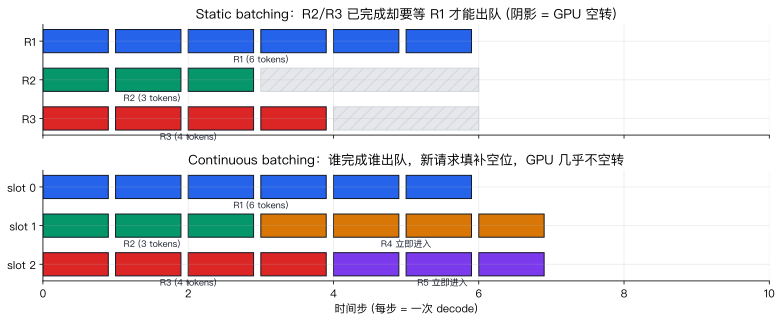

这就是 vLLM / TGI / TensorRT-LLM 在生产环境里普遍启用 continuous batching 的原因：
短请求不再被长请求拖住, 单位时间处理请求数明显提升。


In [41]:
# Static batching vs Continuous batching 示意
# 3 个请求, 长度不等: R1=6, R2=3, R3=4
fig, axes = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)

def draw_tokens(ax, y, start, count, color, label=None):
    for i in range(count):
        ax.barh(y, 0.9, left=start + i, color=color, edgecolor=COLORS["dark"], height=0.6)
    if label:
        ax.text(start + count / 2, y + 0.55, label, ha="center", fontsize=9, color=COLORS["dark"])

# ---- Static batching: 短请求必须等长请求跑完 ----
ax = axes[0]
draw_tokens(ax, 0, 0, 6, COLORS["blue"],  "R1 (6 tokens)")
draw_tokens(ax, 1, 0, 3, COLORS["green"], "R2 (3 tokens)")
draw_tokens(ax, 2, 0, 4, COLORS["red"],   "R3 (4 tokens)")
# 空转区域
for y, done in [(1, 3), (2, 4)]:
    ax.barh(y, 6 - done, left=done, color="#e5e7eb", edgecolor="#d1d5db", hatch="//", height=0.6)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["R1", "R2", "R3"])
ax.set_title("Static batching：R2/R3 已完成却要等 R1 才能出队 (阴影 = GPU 空转)")
ax.set_xlim(0, 10)
ax.invert_yaxis()

# ---- Continuous batching: 完成就出队, 新请求随时加入 ----
ax = axes[1]
draw_tokens(ax, 0, 0, 6, COLORS["blue"],  "R1 (6 tokens)")
draw_tokens(ax, 1, 0, 3, COLORS["green"], "R2 (3 tokens)")
draw_tokens(ax, 2, 0, 4, COLORS["red"],   "R3 (4 tokens)")
# R2 完成后 R4 立刻进来, R3 完成后 R5 立刻进来
draw_tokens(ax, 1, 3, 4, COLORS["amber"], "R4 立即进入")
draw_tokens(ax, 2, 4, 3, COLORS["purple"], "R5 立即进入")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["slot 0", "slot 1", "slot 2"])
ax.set_title("Continuous batching：谁完成谁出队，新请求填补空位，GPU 几乎不空转")
ax.set_xlabel("时间步 (每步 = 一次 decode)")
ax.set_xlim(0, 10)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("这就是 vLLM / TGI / TensorRT-LLM 在生产环境里普遍启用 continuous batching 的原因：")
print("短请求不再被长请求拖住, 单位时间处理请求数明显提升。")

### 13.8 常见线上问题对照

把前面几节的内容汇总成一张"症状 → 原因 → 处理"表：

| 症状 | 常见原因 | 工程处理 |
|---|---|---|
| **请求过长**：首 token 慢，挤占 KV cache | prefill 计算量随 `T²` 增长 | 限制上下文长度、检索裁剪、摘要压缩、长文任务异步化 |
| **输出不可控**：JSON 解析失败、格式漂移、答案过长 | 纯 sampling 无约束 | schema 约束、stop 词、max tokens、低温采样、失败重试 |
| **GPU 利用率低**：单请求 decode 时 GPU 空转 | 无 batching | continuous batching、多用户队列、合并短请求 |
| **显存不足**：长上下文或高并发触发 OOM | KV cache 爆炸 | 量化、GQA/MQA、PagedAttention、降低并发或上下文上限 |
| **首 token 快但流式慢** | decode 吞吐瓶颈 | speculative decoding、更小的 draft 模型、KV cache 优化 |
| **偶发重复或跑题** | 采样参数不合适 | 调 temperature / top-p / repetition penalty |

### 13.9 推理优化补充：量化、prefix caching、chunk prefill 等

前面几节把主线优化都讲了。这里补齐 13.1/13.8 表格里出现过但还没展开的几个重要技巧。

**A. 量化 (Quantization)** — 最基础的显存优化

把权重（有时也包括激活）从 FP16/BF16（2 字节）压到更低精度：

| 精度 | 每参数字节 | 典型代表 | 精度损失 |
|---|---|---|---|
| FP16 / BF16 | 2 | 训练与默认推理 | 无 |
| INT8 (W8A8) | 1 | LLM.int8()、SmoothQuant | 很小 |
| INT4 / NF4 | 0.5 | **GPTQ、AWQ、QLoRA (NF4)** | 中等，可接受 |
| INT2 / 1-bit | ~0.125 | BitNet 系列 | 大，特殊架构 |

**直接后果**：LLaMA-3-70B FP16 需要 140GB 显存，INT4 只要 ~35GB，一张 H100 就够。**GPTQ / AWQ** 是当前开源社区最主流的两种权重量化方案，配合 vLLM/llama.cpp 直接跑。

**B. Prefix Caching / Prompt Caching** — 系统 prompt 免费复用

多轮对话或多个用户共享同一段长 system prompt 时，如果每次都重新 prefill 一遍这段前缀，浪费巨大。**Prefix caching 让 KV cache 按前缀 hash 复用**：

- 第一次 prefill 完，缓存住 `system prompt` 部分的 KV。
- 后续请求发现前缀相同，直接复用，跳过这段的 prefill。
- **实际效果**：长系统 prompt + 短用户输入的场景，首 token 延迟能降 5–10 倍。

vLLM 的 `--enable-prefix-caching`、SGLang 的 RadixAttention、Anthropic 的 prompt caching API 都是这个思路。

**C. Chunk Prefill** — 长 prompt 和 decode 混跑

传统 serving 里，一个 32k prompt 的 prefill 会**独占 GPU 几百毫秒**，期间其他用户的 decode 全部卡住。chunk prefill 把长 prompt 切成小块（例如每块 512 token），**每步只处理一小块 prefill + 若干 decode 请求**，让长请求不再拖住短请求。

vLLM/TGI/TensorRT-LLM 现在默认都开这个。

**D. Prompt 压缩** — 少送 token 就是省钱省时

**LLMLingua**、**LongLLMLingua** 一类的方法用一个小模型评估每个 token 的重要性，删除冗余 token，压缩率通常 2–4x，主要用途是 RAG 上下文塞进窗口 + 降低 API 成本。

**E. 应用侧组合拳** — 表格式速览

剩下几项属于工程组合，一句话搞定：

| 手段 | 一句话说明 | 属于哪一层 |
|---|---|---|
| **控制历史长度** | 多轮对话只保留最近 N 轮或滑动窗口 | 应用/编排 |
| **检索裁剪 (RAG)** | 用向量检索抽取相关片段，替代无脑塞全文 | 应用/RAG |
| **摘要压缩** | 老对话摘要成一小段，节省 token | 应用/编排 |
| **异步化** | 长文任务走后台队列，不阻塞前端 | 应用/架构 |
| **失败重试 + 幂等** | 网络/超时/schema 失败自动重试，带 idempotency key 防重复计费 | 应用/网关 |
| **多租户队列** | 按租户/优先级隔离请求，避免"大户吃满 GPU" | serving |
| **合并短请求** | 短 prompt 请求打包一起 prefill，提升 GPU 利用率 | serving |
| **降低并发或上下文上限** | 直接限流/限长，最简单的兜底手段 | 网关 |

### 13.10 本章小结

- **Prefill 决定首 token 前要处理多少上下文，decode 决定后续 token 的生成速度**。
- **KV cache 能减少重复计算**，但会随层数、上下文长度和并发占用显存。
- **上下文窗口不是长期记忆**，只是当前请求的可见范围；temperature/top-k/top-p 只改变采样方式，不增加事实知识。
- **量化、prefix caching、chunk prefill** 是现代 serving 三大常开优化，vLLM 等框架默认支持。
- 线上优化要同时看质量、延迟、吞吐、显存和成本，**不能只盯模型大小**。

## 14 · 总结、速查表和后续路线

| 路线 | 结构 | 训练目标 | 能看见什么 | 典型用途 |
|---|---|---|---|---|
| Original Transformer | Encoder-Decoder | target token prediction | encoder 双向；decoder 因果；cross 看 source | 翻译、摘要、结构化生成 |
| GPT | Decoder-only | next-token prediction | 只能看左侧历史 | 文本生成、对话、代码生成 |
| BERT | Encoder-only | masked language modeling | 双向上下文 | 分类、检索、抽取、表征 |

### 你现在应该能回答的问题

1. 为什么 attention 需要 `Q/K/V` 三组向量？
2. `QK^T / sqrt(d_k)` 每一项分别代表什么？
3. padding mask 和 causal mask 的 shape 为什么不同？
4. Encoder self-attention、Decoder self-attention、Cross-attention 的 Q/K/V 分别来自哪里？
5. 为什么 GPT 适合生成，而 BERT 适合理解和表征？
6. PyTorch 实现里 logits、labels、mask 的 shape 应该如何对齐？

### 自测参考答案

| 问题 | 简短答案 |
|---|---|
| Q/K/V 为什么分开？ | `Q` 表示“我想找什么”，`K` 表示“我有什么索引特征”，`V` 表示“真正被取走的信息”。分开后模型可以用不同投影学习检索关系和内容表示。 |
| 为什么除以 `sqrt(d_k)`？ | 点积是 `d_k` 个随机项相加，维度越大 score 方差越大；缩放后 softmax 不容易过早饱和。 |
| padding mask vs causal mask？ | padding mask 遮掉无意义的 `<pad>` key；causal mask 遮掉未来位置，防止生成任务偷看答案。 |
| cross-attention 的 Q/K/V 来自哪里？ | Q 来自 decoder hidden state；K/V 来自 encoder memory。 |
| GPT 和 BERT 的根本差别？ | GPT 只能看左侧历史，适合自回归生成；BERT 能看双向上下文，适合理解和表征。 |
| logits/labels 如何对齐？ | logits 通常是 `[B,T,V]`，labels 是 `[B,T]`；做 CE 前把 logits reshape 成 `[B*T,V]`，labels reshape 成 `[B*T]`。 |

### 实践 checklist

从零实现一个小 Transformer 时，按这个顺序排查：

1. 先只跑一个 batch，确认 `embedding -> attention -> logits` shape 全部正确。
2. 打印 mask 矩阵，确认 `<pad>` 列和未来列被遮住。
3. 在 toy 数据上 overfit，loss 必须下降，token accuracy 必须上升。
4. 再做 greedy decode 或 sampling，看样本级输出是否符合任务定义。
5. 最后再考虑更大数据、更多层、GPU/MPS、混合精度和 KV cache。

如果 toy 数据都不能 overfit，问题通常不是“模型不够大”，而是 label shift、mask、padding 或 loss ignore 出错。

### 现代 LLM 组件替换速查表

教程主线讲的是 2017 原版 Transformer。现代大模型（LLaMA、Qwen、Mistral、DeepSeek 等）几乎每一个基础组件都换过。下表是横向对比，同时回链到教程中展开讲解的位置：

| 组件 | 2017 原版 | 现代 LLM 主流 | 教程位置 |
|---|---|---|---|
| Tokenizer | 手工词表 / word-level | **Byte-level BPE**（32k–200k 词表） | 2.5 |
| 位置编码 | Sinusoidal（加到 embedding） | **RoPE**（旋转 Q/K），或 ALiBi | 2.1 – 2.4 |
| 归一化 | LayerNorm（Post-Norm） | **RMSNorm + Pre-Norm** | 7.2 – 7.4 |
| FFN 结构 | 单路 ReLU/GELU FFN | **SwiGLU 门控 FFN** | 7.5 – 7.8 |
| Attention K/V | MHA（每头独立 K/V） | **GQA / MQA**（K/V 共享） | 5.1 |
| KV cache | 无（原版只讲训练） | 生成时必备 | 12.4.1 |
| 微调方式 | 全参微调 | LoRA / QLoRA 等 PEFT | 仅点名，见 14 章末尾"后续路线" |

**横向观察**：这几处替换共享同一条主线——**做减法 + 加门控**：

- 位置编码：去掉可学习的位置 embedding 表，改用无参数的旋转（RoPE）或线性偏置（ALiBi）。
- 归一化：去掉 LayerNorm 的“减均值”和 `β`，只保留 re-scaling。
- FFN：去掉 ReLU 的硬切，加一路门控（SwiGLU），并把 `d_ff` 从 `4d` 压到 `~2.67d` 平衡参数量。

这条主线的目的都是：**在保持或提升效果的前提下，让模型更省参数、更省显存、更容易外推到长上下文。**

### 后续阅读

- Vaswani et al. (2017). *Attention Is All You Need.*
- Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.*
- Radford et al. (2018). *Improving Language Understanding by Generative Pre-Training.*
- Radford et al. (2019). *Language Models are Unsupervised Multitask Learners.*
- Jay Alammar. *The Illustrated Transformer.*
- Harvard NLP. *The Annotated Transformer.*

到这里，你已经从公式、图、手算、mask、PyTorch 模块、toy 训练任务和工程常见坑几个角度走完了 Transformer 的主干。下一步如果继续深入，建议按两个方向走：

- 工程方向：学习 tokenizer、batching、mixed precision、distributed training、KV cache 实现。
- 算法方向：学习 RoPE、Pre-LN/Post-LN、RMSNorm、SwiGLU、MQA/GQA、LoRA、instruction tuning。